# NFLELO, end to end: the master walkthrough

This notebook walks through the whole NFLELO project in one place: the data, Elo v2, the leak-proof features, how every model was tested, each model and its result, the live 2026 pipeline, and what is still waiting on data. It is written for you, Walker, as the author of the original 2025 Elo paper, so it assumes you know Elo and Brier scores and explains everything built since.

Every code cell calls the project's real code in `nflelo/` (and, where a milestone's script holds the glue, `scripts/ml_*.py`). Nothing is copied. The ten numbered notebooks (`01` to `10`) go deeper on each piece; each section here links to the right one.

**Two kinds of numbers.** Each code cell starts with a comment saying which kind it shows:

- `# LIVE:` the cell computes the number right now, from cached data, on seasons that are allowed (training and development seasons, or the live 2026 season).
- `# LOADED:` the cell reads a number that was logged earlier, and names the file. Every result on the locked 2020-2025 test seasons is loaded, never recomputed: those seasons were scored once per model, and this notebook doesn't score them again.

Some loaded files live in `data/raw/ml/` (local outputs, not in git). If one is missing on another machine, the cell says so and moves on instead of crashing.

**License.** The game model, Elo and the win-probability model are CC BY 4.0. Sections 8 (on-field ratings), 10 and 11 (the play model, the fourth-down go option and early-down play calling) show outputs derived from nflverse participation data (NFL Next Gen Stats 2016-2022, FTN 2023+), which is CC BY-SA 4.0, so treat this notebook as a whole as CC BY-SA 4.0. Data: nflverse (CC BY 4.0); 1970-1998 results: FiveThirtyEight (CC BY 4.0).

**Contents**

0. Start here: what NFLELO is, the map, the scoreboard
1. Data: sources, licenses, the cache, one play explained
2. Elo v2
3. Leak-proof features
4. How we test
5. The game model (A4s)
6. Margin model and playoff odds
7. The live 2026 pipeline
8. Player value (M5 and M5b)
9. The Kalman shadow model (M3b)
10. The play model (M6)
11. Decision support (M7)
12. Where it stands, what's next, and a glossary

In [1]:
# LIVE: setup. Imports, chart style, and small helpers used throughout.
import json, subprocess, sys, time, warnings
from datetime import date, datetime, timezone
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nflelo").is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))     # milestone scripts hold some glue code; we import, never edit
warnings.filterwarnings("ignore")
NB_START = time.perf_counter()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from nflelo import config, data as elo_data, evaluate
from nflelo.elo import run_elo
from nflelo.ml import data as D, asof, registry, live
from nflelo.ml.eval import baselines, bootstrap, calibration, metrics, windows

%config InlineBackend.figure_format = "png"
plt.rcParams.update({"figure.figsize": (9, 3.6), "figure.dpi": 90, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
                     "axes.titlesize": 11, "legend.frameon": False})
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# Series colors match the site: Elo blue, model violet, Vegas orange (a benchmark only).
ELO, MODEL, VEGAS = "#3a5979", "#7b4fc9", "#c9501c"
INK, MUTED, GOOD, BAD = "#1c2126", "#9aa3b2", "#2a9d8f", "#d1495b"

RUNS = sorted(registry.load_runs(), key=lambda r: r["timestamp"])   # every logged run, oldest first

def run(name):
    "Newest logged run with this name (experiments/runs/*.json)."
    hits = [r for r in RUNS if r["name"] == name]
    if not hits:
        raise KeyError(f"no run named {name}")
    return hits[-1]

def ci(c, nd=4):
    "Format a logged comparison as 'diff [low, high]'."
    return f"{c['diff']:+.{nd}f} [{c['ci_low']:+.{nd}f}, {c['ci_high']:+.{nd}f}]"

def need(path):
    "Gitignored local outputs may be missing on another machine: say so instead of crashing."
    p = Path(path)
    if not p.exists():
        print(f"(skipped: {p.relative_to(ROOT)} is a local output that isn't on this machine; "
              "rerun the milestone script to regenerate it)")
        return None
    return p

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print(f"repo: {ROOT}")
print(f"{len(RUNS)} logged runs in experiments/runs; nflverse cache in {D.ML_DIR.relative_to(ROOT)}: "
      f"{'present' if (D.ML_DIR / D.MANIFEST_NAME).exists() else 'MISSING (cells that need it will download or skip)'}")

repo: /Users/walker_tracy/Desktop/NFLELO
132 logged runs in experiments/runs; nflverse cache in data/raw/ml: present


## 0. Start here

### What NFLELO is

NFLELO is a portfolio piece aimed at NFL front offices. It started from your 2025 Elo paper (1970-2024 regular seasons) and grew into a full modeling project on free, commercially safe data:

- **Elo v2**, rebuilt on nflverse and FiveThirtyEight data, with a learned home-field advantage.
- **A machine-learning track (milestones M1 to M7)**: a game model that beats Elo, a margin model, playoff odds, player values, a play-outcome model, a win-probability model, and decision support for fourth downs and early-down play calling.
- **A live 2026 record**: every prediction is written to a public ledger before kickoff.
- **A static website** (`site/`) that shows all of it. It isn't hosted yet.

There are no betting features: no picks against the spread, no units, no sportsbook offers. The betting market (Vegas) appears only as a benchmark to measure against, and it is never a model input. The goal is work a front office would respect: clear methods, honest uncertainty, and results anyone can verify.

### The map

| Piece | Where | What it does |
|---|---|---|
| Game data | `nflelo/data.py` → `data/games.csv` | 1970-1998 from FiveThirtyEight, 1999 on from nflverse, one row per game |
| Elo v2 | `nflelo/elo.py`, `nflelo/config.py` | Ratings, learned home field, the baseline every model must beat |
| nflverse cache | `nflelo/ml/data.py` → `data/raw/ml/` | Play-by-play, schedules, players, participation, with a hash manifest |
| As-of rule | `nflelo/ml/asof.py` | Decides what a prediction may know; includes the leakage test |
| Features | `nflelo/ml/features/` | Opponent-adjusted EPA, QB value, rest, the Kalman filter, roster terms |
| Models | `nflelo/ml/models/`, `sim/`, `players/`, `plays/`, `wp/`, `decisions/` | Game, margin, season simulation, player values, play model, WP, fourth down, play calling |
| Evaluation | `nflelo/ml/eval/`, `nflelo/ml/registry.py` | Metrics, bootstrap intervals, calibration, season windows, the run log |
| Run log | `experiments/runs/*.json` | One file per scored run, with its git commit (the receipts) |
| Milestone scripts | `scripts/ml_m3.py` ... `scripts/ml_m7b.py` | Each milestone's tuning, dev runs, and one-time sign-off |
| Live pipeline | `scripts/build.py`, `scripts/ml_predict.py`, `scripts/export_site.py`, `.github/workflows/weekly.yml` | Wednesday and Sunday: rebuild, predict, log, export |
| Live ledgers | `experiments/live/` | 2026 predictions (append-only), the shadow model, the playoff-odds history |
| Site | `site/` (+ `site/data/*.json`) | Ratings page and models page; reads JSON only |
| Docs | `CONTEXT.md`, `context/*.md`, `HANDOFF.md` | Decisions, methods, results, session log |

The flow below shows how the pieces feed each other.

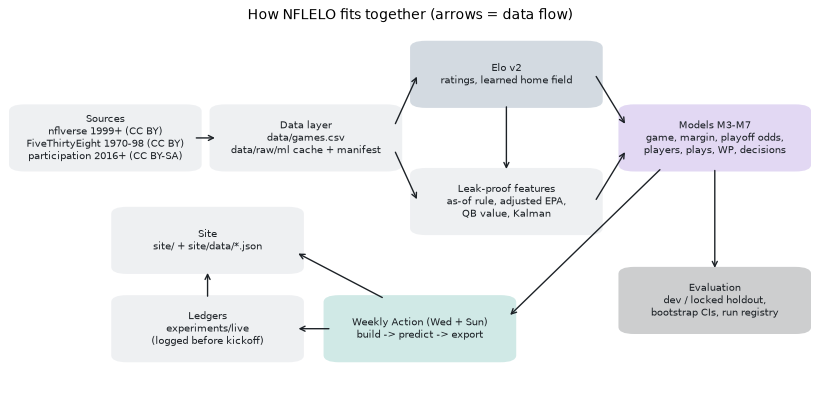

In [2]:
# LIVE: a small flow diagram of the project (drawn with matplotlib).
from matplotlib.patches import FancyBboxPatch

boxes = {
    "src":   (0.00, 0.62, "Sources\nnflverse 1999+ (CC BY)\nFiveThirtyEight 1970-98 (CC BY)\nparticipation 2016+ (CC BY-SA)"),
    "data":  (0.255, 0.62, "Data layer\ndata/games.csv\ndata/raw/ml cache + manifest"),
    "elo":   (0.51, 0.80, "Elo v2\nratings, learned home field"),
    "feat":  (0.51, 0.44, "Leak-proof features\nas-of rule, adjusted EPA,\nQB value, Kalman"),
    "mod":   (0.775, 0.62, "Models M3-M7\ngame, margin, playoff odds,\nplayers, plays, WP, decisions"),
    "eval":  (0.775, 0.16, "Evaluation\ndev / locked holdout,\nbootstrap CIs, run registry"),
    "live":  (0.40, 0.08, "Weekly Action (Wed + Sun)\nbuild -> predict -> export"),
    "led":   (0.13, 0.08, "Ledgers\nexperiments/live\n(logged before kickoff)"),
    "site":  (0.13, 0.33, "Site\nsite/ + site/data/*.json"),
}
W, H = 0.225, 0.17
fig, ax = plt.subplots(figsize=(11.5, 5.2))
ax.set_xlim(-0.01, 1.01); ax.set_ylim(0, 1.02); ax.axis("off")
colors = {"elo": ELO, "mod": MODEL, "eval": INK, "live": GOOD}
for k, (x, y, label) in boxes.items():
    c = colors.get(k, MUTED)
    ax.add_patch(FancyBboxPatch((x, y), W, H, boxstyle="round,pad=0.01,rounding_size=0.02",
                                fc=c, ec="none", alpha=0.16 if k not in colors else 0.22))
    ax.text(x + W / 2, y + H / 2, label, ha="center", va="center", fontsize=8, color=INK)

def arrow(a, b, dx0=0.5, dy0=0.5, dx1=0.5, dy1=0.5):
    (x0, y0, _), (x1, y1, _) = boxes[a], boxes[b]
    ax.annotate("", xy=(x1 + W * dx1, y1 + H * dy1), xytext=(x0 + W * dx0, y0 + H * dy0),
                arrowprops=dict(arrowstyle="->", color=INK, lw=1.1, shrinkA=2, shrinkB=2))

arrow("src", "data", 1, .5, 0, .5); arrow("data", "elo", 1, .7, 0, .5); arrow("data", "feat", 1, .3, 0, .5)
arrow("elo", "mod", 1, .5, 0, .7); arrow("feat", "mod", 1, .5, 0, .3); arrow("elo", "feat", .5, 0, .5, 1)
arrow("mod", "eval", .5, 0, .5, 1); arrow("mod", "live", .2, 0, 1, .7); arrow("live", "led", 0, .5, 1, .5)
arrow("live", "site", .3, 1, 1, .3); arrow("led", "site", .5, 1, .5, 0)
ax.set_title("How NFLELO fits together (arrows = data flow)")
plt.show()

### The scoreboard

Every model was developed on earlier seasons, then judged **once** on the locked 2020-2025 seasons, under pass/fail rules committed to git before that run. The table below is loaded from `site/data/research.json` (written by `scripts/export_research.py` from the run registry), and each row's number is checked against the run file it cites. "Rules → result" are the two commits: the rules were public before the result existed.

In [3]:
# LOADED: site/data/research.json (the models page data), cross-checked against experiments/runs/*.json.
research = json.loads((ROOT / "site" / "data" / "research.json").read_text())
rows = []
for m in research["models"]:
    p = m["primary"]
    src = ROOT / p["source"]
    rec = json.loads(src.read_text()) if src.exists() else None
    rows.append({"id": m["id"], "model": m["name"], "locked 2020-25 test": "yes" if m["tested_holdout"] else "no (dev only)",
                 "primary measure": p["label"], "result": p["text"], "verdict": m["verdict_label"],
                 "license": m["license"],
                 "rules -> result": f"{m.get('rules_commit') or '-'} -> {m.get('result_commit') or '-'}",
                 "run file found": rec is not None})
board = pd.DataFrame(rows).set_index("id")
print(research["headlines"]["hero"])
print(research["headlines"]["scoreboard"])
board

8 models tested once on seasons they never saw. 5 passed, 3 failed.
5 passed, 3 failed, 1 negative result, 1 not yet tested.


,model,locked 2020-25 test,primary measure,result,verdict,license,rules -> result,run file found
id,,,,,,,,
M3,Game model,yes,"Brier score, model minus Elo (lower is better)","-0.0035 [-0.0063, -0.0007]",Pass,CC BY,eb65d61 -> 5a66c9a,True
M4-margin,Margin model,yes,"Average margin error in points, model minus El...","-0.059 [-0.150, +0.035]",Fail,CC BY,e51e890 -> 816c327,True
M4-odds,Playoff odds,yes,"Made-playoffs Brier score, with strength shock...","-0.0024 [-0.0049, -0.0001]",Pass,CC BY,e51e890 -> 816c327,True
M5,Lineup values,no (dev only),"Brier score, best lineup model minus the game ...","+0.0008 [-0.0004, +0.0019]",Negative result,CC BY,- -> a91d8a3,True
M5b,On-field player ratings,yes,"Play-level squared error, RAPM minus box-score...","+0.0010 [+0.0002, +0.0018]",Fail,CC BY-SA,8956c97 -> e83f7ac,True
M3b,Kalman strength model,no (dev only),"Brier score, Kalman candidate minus the live m...","-0.0010 [-0.0019, +0.0000]","Not tested, shadow live",CC BY,- -> ca705de,True
M6,Play outcome model,yes,"Yards error (CRPS), model minus the situation ...","-0.0181 [-0.0198, -0.0164]",Pass,CC BY-SA,bc0bff7 -> fe61c0e,True
M7a-wp,Win-probability model,yes,"Brier score, our model minus nflfastR (lower i...","-0.0099 [-0.0146, -0.0055]",Pass,CC BY,a4a24b1 -> 4e509da,True
M7a-4th,Fourth-down tool,yes,Go-for-it conversion calibration error (ECE) a...,0.027 against a limit of 0.022,Fail,CC BY-SA,a4a24b1 -> 4e509da,True


How to read it: **Pass** means the model met every pre-registered rule on seasons it never saw. **Fail** means it missed at least one, and it is reported anyway. **Negative result** (M5) means the idea showed no gain even on development seasons, so it never earned a locked test. **Not tested, shadow live** (M3b) means it narrowly missed its development bar, so instead of testing it on the spent holdout it runs alongside the live model in 2026 as a clean forward test.

**How to read the rest of the notebook.** Each section opens with plain-English context, then alternates short explanations and code. Charts use Elo blue, model violet and Vegas orange throughout. The glossary at the end defines every term (Brier, ECE, EPA, CRPS, RAPM, AIPW, OPE and the rest).

## 1. Data

### Sources and the licensing rules

The project has two hard constraints: the data must be **free**, and it must be **safe for commercial use** (in case NFLELO is ever more than a portfolio). That decides every source:

| Source | Seasons | License | Used for |
|---|---|---|---|
| nflverse schedules and results | 1999 on | CC BY 4.0 | Games, scores, starting QBs, rest, moneylines (benchmark only) |
| nflverse play-by-play (nflfastR) | 1999 on | CC BY 4.0 | EPA, situations, every model's play data |
| FiveThirtyEight NFL Elo game file | 1970-1998 used | CC BY 4.0 | The pre-1999 games (vendored in `data/sources/` with its hash) |
| nflverse participation (NGS 2016-2022, FTN 2023+) | 2016 on | **CC BY-SA 4.0** | Who was on the field, personnel, formation (M5b, M6, M7) |
| Pro-Football-Reference | none | **Banned** | Its terms forbid substitute databases and machine-learning use |

**Why CC BY vs CC BY-SA matters.** CC BY only requires credit. CC BY-SA adds share-alike: anything built from that data must carry the same license. So the project keeps a hard wall between the two. The game model, Elo and the WP model use only CC BY data. The personnel-based models (on-field ratings, the play model, the fourth-down go option, play calling) are CC BY-SA, and tests in `tests/ml/` stop CC BY modules from importing them.

**Why Pro-Football-Reference is out.** Your legacy spreadsheet came from Pro-Football-Reference, whose terms restrict building substitute databases and machine-learning use. It was removed from the public repo and its git history, and 1970-1998 now comes from FiveThirtyEight's CC BY file. The two agree on all 6,140 regular-season games from 1970 to 1998, so nothing in the ratings changed.

**The cache and manifest.** `nflelo/ml/data.py` downloads each nflverse dataset once per season into `data/raw/ml/` (gitignored, about 300 MB of play-by-play) and records rows, a SHA-256 hash and a fetch time in `manifest.json`. Every season is schema-checked on load (required columns, plays per game, team codes that map to a franchise). Betting-market columns are dropped as the data loads, so feature code never sees them.

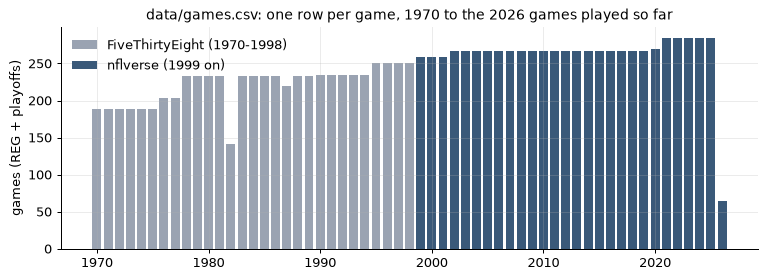

13,749 games, 1970-2026; REG 13,171, playoffs 578; 2026 so far: 64 games through week 4


In [4]:
# LIVE: coverage of data/games.csv (the Elo game file), by season and source.
games = elo_data.load_games()
cov = games.groupby(["season", "source"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(cov.index, cov.get("fivethirtyeight", 0), color=MUTED, label="FiveThirtyEight (1970-1998)")
ax.bar(cov.index, cov.get("nflverse", 0), bottom=cov.get("fivethirtyeight", 0), color=ELO, label="nflverse (1999 on)")
ax.set_ylabel("games (REG + playoffs)"); ax.set_title("data/games.csv: one row per game, 1970 to the 2026 games played so far")
ax.legend(loc="upper left"); plt.show()
print(f"{len(games):,} games, {games['season'].min()}-{games['season'].max()}; "
      f"REG {int((games['game_type'] == 'REG').sum()):,}, playoffs {int((games['game_type'] != 'REG').sum()):,}; "
      f"2026 so far: {int((games['season'] == 2026).sum())} games through week {int(games.loc[games['season'] == 2026, 'week'].max())}")

In [5]:
# LIVE: what is in the nflverse cache, from its manifest (data/raw/ml/manifest.json).
man = D.read_manifest()
if man:
    mf = pd.DataFrame([{"dataset": k.split("/")[0], "season": int(k.split("/")[1]), "rows": v["rows"]} for k, v in man.items()])
    mf = mf[mf["season"] > 0]
    summary = mf.groupby("dataset").agg(first=("season", "min"), last=("season", "max"), files=("season", "size"), rows=("rows", "sum"))
    summary["license"] = np.where(summary.index == "participation", "CC BY-SA 4.0", "CC BY 4.0")
    display(summary.sort_values("rows", ascending=False))
else:
    print("(no manifest: the nflverse cache isn't on this machine; `python -m nflelo.ml.data fetch` builds it)")

,first,last,files,rows,license
dataset,,,,,
pbp,1999,2026,28,1290607,CC BY 4.0
depth_charts,2005,2025,21,1288874,CC BY 4.0
rosters_weekly,2002,2025,24,906378,CC BY 4.0
participation,2016,2025,10,478989,CC BY-SA 4.0
player_stats,1999,2019,21,363709,CC BY 4.0
injuries,2009,2025,17,90752,CC BY 4.0
schedules,1999,2026,28,7548,CC BY 4.0


### One play, explained

nflverse records every snap since 1999: one row per play with about 370 columns. Most are bookkeeping. The handful the models use describe the **situation** (down, distance, field position, clock), **what happened** (play type, yards), and two model outputs from nflfastR:

- **EP (expected points):** how many points the offense can expect from this down, distance and spot, averaged over history. Your own 40 on 1st and 10 is worth about +1.5.
- **EPA (expected points added):** EP after the play minus EP before. A 20-yard completion might be +1.4; a sack about -1.5. EPA per play is the core efficiency number in everything below.
- **WP (win probability)** is nflfastR's estimate that the offense wins. We use it only to drop garbage time and as a benchmark; section 11 builds our own.

Here is Lamar Jackson's first pass of 2019.

In [6]:
# LIVE: one 2019 play-by-play row (development data), and proof that market columns never load.
pbp19 = D.load_pbp([2019])
row = pbp19[(pbp19["posteam"] == "BAL") & (pbp19["week"] == 1) & (pbp19["play_type"] == "pass")
            & (pbp19["passer_player_name"] == "L.Jackson")].iloc[0]
cols = ["game_id", "qtr", "time", "down", "ydstogo", "yardline_100", "posteam", "defteam", "play_type",
        "yards_gained", "ep", "epa", "success", "wp", "desc"]
display(row[cols].to_frame("value"))
print(f"columns loaded: {pbp19.shape[1]}; plays in 2019: {len(pbp19):,}")
print("betting-market columns left after loading:", [c for c in pbp19.columns if D.is_market_column(c)])
del pbp19

,value
game_id,2019_01_BAL_MIA
qtr,1.0
time,14:09
down,1.0
ydstogo,10.0
yardline_100,40.0
posteam,BAL
defteam,MIA
play_type,pass
yards_gained,7.0


columns loaded: 366; plays in 2019: 47,260
betting-market columns left after loading: []


Read the row like this: 1st and 10 at the Miami 40 (`yardline_100` is yards to the end zone). The play's `ep` is the expected points before the snap, and `epa` is how much the play added. `success` is 1 when EPA is positive. `wp` is nflfastR's win probability for Baltimore before the snap. The betting columns (`spread_line`, `vegas_wp`, and the rest) are gone: decision D3 says the market is a benchmark we score against, never an input, so the loader removes it. For a longer tour, including the 2019 Ravens' EPA week by week, see `notebooks/01_data_tour_and_leakage.ipynb`.

## 2. Elo v2

Elo v2 is your paper's model, rebuilt and re-tuned. The engine is the same idea (538-style margin-of-victory multiplier, season regression), with four changes, each chosen on tuning seasons 1980-2009 and checked on 2010-2025:

- **Learned home field.** Instead of a fixed 55 points, home field starts at 65 in 1970 and updates after every game by `0.5 × (actual − expected)`. The home edge has fallen from about 60% home wins in the 1990s to about 53% in the 2020s, and a fixed number can't follow that.
- **More regression between seasons:** λ 0.40 instead of 0.15. Your sensitivity grid's best value sat at its edge (0.2), which hinted at this; a wider grid tuned on held-out seasons found 0.40.
- **Expansion teams start at 1300**, not the league average.
- **Playoffs are predicted but don't update ratings.** Updating on them was tested and didn't help.

The scale moved from 1000 to 1500; only differences between ratings matter, so that changes nothing. In the table below, `hfa` applies only in fixed mode, and `hfa_init` and `k_hfa` only in online mode.

In [7]:
# LIVE: the two configurations side by side (nflelo/config.py).
cfgs = pd.DataFrame({"legacy (2025 paper)": config.LEGACY_CONFIG.to_dict(), "Elo v2 (DEFAULT_CONFIG)": config.DEFAULT_CONFIG.to_dict()})
cfgs.loc[["start", "k", "lam", "hfa_mode", "hfa", "hfa_init", "k_hfa", "mov_mode", "mov_cap", "expansion_start", "include_playoffs"]]

,legacy (2025 paper),Elo v2 (DEFAULT_CONFIG)
start,1500.0,1500.0
k,20.0,20.0
lam,0.15,0.4
hfa_mode,fixed,online
hfa,55.0,55.0
hfa_init,65.0,65.0
k_hfa,1.0,0.5
mov_mode,abs,winner
mov_cap,2.0,None
expansion_start,1500.0,1300.0


Elo over 13,749 games in 0.01s; home field now 37.0 Elo points
Current top five: SEA 1639, SF 1626, JAX 1615, MIN 1611, BUF 1611 | bottom three: MIA 1388, NYJ 1375, TEN 1321


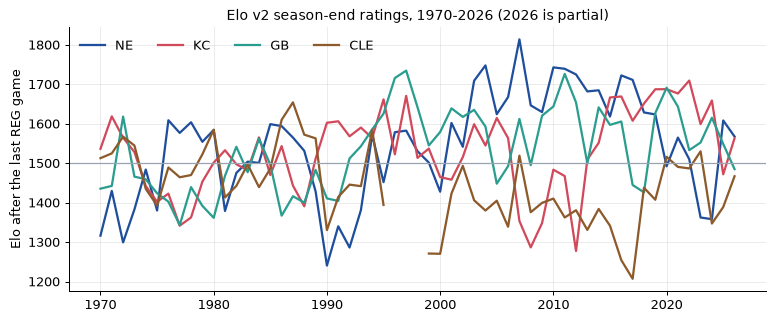

In [8]:
# LIVE: run Elo v2 over every game from 1970 to the latest played game.
t0 = time.perf_counter()
elo_out, elo_state = run_elo(games, config.DEFAULT_CONFIG)
print(f"Elo over {len(elo_out):,} games in {time.perf_counter() - t0:.2f}s; home field now {elo_state['hfa']:.1f} Elo points")
top = pd.Series(elo_state["ratings"]).sort_values(ascending=False)
print("Current top five:", ", ".join(f"{t} {v:.0f}" for t, v in top.head(5).items()),
      "| bottom three:", ", ".join(f"{t} {v:.0f}" for t, v in top.tail(3).items()))

# Season-end rating per team (last regular-season game), for a few franchises.
reg = elo_out[elo_out["game_type"] == "REG"]
long = pd.concat([reg[["season", "date", "home", "home_post"]].rename(columns={"home": "team", "home_post": "rating"}),
                  reg[["season", "date", "away", "away_post"]].rename(columns={"away": "team", "away_post": "rating"})])
end = long.sort_values("date").groupby(["season", "team"])["rating"].last().unstack()
fig, ax = plt.subplots(figsize=(10, 3.8))
for t, colr in {"NE": "#1f4e9c", "KC": BAD, "GB": GOOD, "CLE": "#8c5a2b"}.items():
    ax.plot(end.index, end[t], lw=1.8, color=colr, label=t)
ax.axhline(1500, color=MUTED, lw=1)
ax.set_ylabel("Elo after the last REG game"); ax.set_title("Elo v2 season-end ratings, 1970-2026 (2026 is partial)")
ax.legend(ncol=4, loc="upper left"); plt.show()

New England's two decades under Belichick and Brady, Kansas City's climb since 2018, Green Bay's long run with Favre and Rodgers, and Cleveland's long stretch below average all show up the way you'd expect. The gap in Cleveland's line is 1996-1998, when the franchise didn't play.

### The learned home-field advantage

The chart compares two things season by season: the home win probability Elo v2's learned home field implies for two equal teams, and the actual home win rate in regular-season games played at the home team's stadium (ties count half).

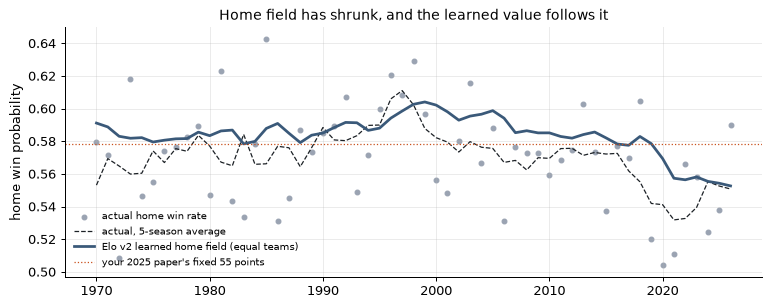

,1970s,1980s,1990s,2000s,2010s,2020s
hfa,58.634,59.028,65.418,65.727,57.429,40.246
actual,0.570,0.570,0.596,0.571,0.569,0.542


In [9]:
# LIVE: learned home field (from the Elo run above) vs the actual home win rate, by season.
r = elo_out[(elo_out["game_type"] == "REG") & (~elo_out["neutral"].astype(bool))].copy()
r["y"] = evaluate.outcome(r)
by = r.groupby("season").agg(hfa=("hfa_used", "mean"), actual=("y", "mean"), n=("y", "size"))
by["implied"] = 1 / (1 + 10 ** (-by["hfa"] / 400))
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.scatter(by.index, by["actual"], s=14, color=MUTED, label="actual home win rate")
ax.plot(by.index, by["actual"].rolling(5, center=True, min_periods=3).mean(), color=INK, lw=1, ls="--", label="actual, 5-season average")
ax.plot(by.index, by["implied"], color=ELO, lw=2.2, label="Elo v2 learned home field (equal teams)")
ax.axhline(1 / (1 + 10 ** (-55 / 400)), color=VEGAS, lw=1, ls=":", label="your 2025 paper's fixed 55 points")
ax.set_ylabel("home win probability"); ax.set_title("Home field has shrunk, and the learned value follows it")
ax.legend(loc="lower left", fontsize=8); plt.show()
dec = by.groupby((by.index // 10) * 10).agg(hfa=("hfa", "mean"), actual=("actual", "mean"))
dec.index = [f"{d}s" for d in dec.index]
dec.round(3).T

The fixed 55 points (dotted) implies about 57.8% for the home side, which fit the 1970s-1990s but is far too high now: 2020s home teams win about 54%. The learned value tracks the decline, which is why Elo v2 uses it.

### How good Elo v2 is

Two windows matter. The **Elo test window** (regular seasons 2010-2025) was set when Elo v2 was built. The **ML development window** (2006-2019) is where every later model was compared with Elo. The 2010-2025 numbers are loaded from the run log because that window includes the locked 2020-2025 seasons; the development numbers are recomputed live.

In [10]:
# LOADED: experiments/runs/20261003T212211Z_elo_v2.json and _market.json (reproduction runs, REG 2010-2025).
repro = {r["name"]: r for r in RUNS if r["label"] == "reproduction"}
print(f"Elo v2, REG 2010-2025:  Brier {repro['elo_v2']['metrics']['brier']:.4f} on {repro['elo_v2']['n']:,} games "
      f"(log loss {repro['elo_v2']['metrics']['logloss']:.4f}, accuracy {repro['elo_v2']['metrics']['accuracy']:.1%})")
print(f"Market (vig removed):   Brier {repro['market']['metrics']['brier']:.4f} on the {repro['market']['n']:,} games with moneylines "
      f"(Elo on those games {repro['elo_v2_market_games']['metrics']['brier']:.4f})")
print("Your 2025 paper's model on the same window scored 0.2244 (context/data-and-elo.md).")

# LIVE: the development window, 2006-2019, where every ML model was compared (no locked seasons touched).
dev = baselines.baseline_frame(games, windows.DEV, require_market=True)
dev_tab = pd.DataFrame({k: {**metrics.win_metrics(dev["y"], dev[c]), "ece": calibration.ece(dev["y"], dev[c])}
                        for k, c in {"market (benchmark)": baselines.MARKET_COL, "Elo v2": "p_elo_v2",
                                     "home-win rate": "p_home_rate", "coin flip": "p_coin_flip"}.items()}).T
c = bootstrap.paired_bootstrap(dev["y"], dev["p_elo_v2"], dev[baselines.MARKET_COL])
print(f"\nDEV 2006-2019, {len(dev):,} games with moneylines. Elo minus market Brier: {ci(c)}")
dev_tab[["n", "brier", "logloss", "accuracy", "ece"]].round(4)

Elo v2, REG 2010-2025:  Brier 0.2201 on 4,175 games (log loss 0.6317, accuracy 64.0%)
Market (vig removed):   Brier 0.2104 on the 4,174 games with moneylines (Elo on those games 0.2201)
Your 2025 paper's model on the same window scored 0.2244 (context/data-and-elo.md).

DEV 2006-2019, 3,450 games with moneylines. Elo minus market Brier: +0.0072 [+0.0044, +0.0101]


,n,brier,logloss,accuracy,ece
market (benchmark),3450.0,0.2106,0.6096,0.6635,0.0182
Elo v2,3450.0,0.2178,0.6255,0.6411,0.0154
home-win rate,3450.0,0.2451,0.6847,0.5661,0.0069
coin flip,3450.0,0.2493,0.6931,0.4339,0.0659


Elo v2 scores 0.2201 on 2010-2025 against 0.2244 for the paper's model. The market (0.2104) is still about 0.01 better, and on the development seasons the gap's interval excludes zero. That gap is the target every ML model in the rest of the notebook chases. The market is scored only as a yardstick.

## 3. Leak-proof features

### The as-of rule

A feature may use only information that existed before the prediction. The project makes that precise with one timestamp per game:

> `as_of` = the earliest kickoff of that game's week (Eastern time).

Every feature for every game in a week is built from games that kicked off strictly before `as_of`. So Sunday's prediction can't see Thursday night's result in the same week. That is stricter than Elo, which updates game by game, and it mirrors the live pipeline: the Wednesday run predicts the whole week at once.

In [11]:
# LIVE: load the M3 inputs (games, play-by-play and schedules through 2019 only) through scripts/ml_m3.py.
import ml_m3
t0 = time.perf_counter()
games3, pbp3, sched3 = ml_m3.load_inputs(2019)
print(f"{len(pbp3):,} plays 1999-2019 loaded in {time.perf_counter() - t0:.0f}s")
wk = sched3[(sched3["season"] == 2019) & (sched3["week"] == 10)].sort_values("kickoff")
wk[["game_id", "kickoff", "as_of"]].head(5)

984,639 plays 1999-2019 loaded in 1s


,game_id,kickoff,as_of
5451,2019_10_LAC_OAK,2019-11-07 20:20:00-05:00,2019-11-07 20:20:00-05:00
5452,2019_10_DET_CHI,2019-11-10 13:00:00-05:00,2019-11-07 20:20:00-05:00
5453,2019_10_BAL_CIN,2019-11-10 13:00:00-05:00,2019-11-07 20:20:00-05:00
5454,2019_10_BUF_CLE,2019-11-10 13:00:00-05:00,2019-11-07 20:20:00-05:00
5455,2019_10_ATL_NO,2019-11-10 13:00:00-05:00,2019-11-07 20:20:00-05:00


Week 10 of 2019 starts with the Thursday game (Chargers at Raiders), so every week-10 game, Sunday and Monday included, gets that Thursday kickoff as its `as_of`.

### Opponent-adjusted EPA ratings

Raw EPA per play rewards easy schedules. The fix is one regression that rates every offense and defense at once. Each team-game is an equation:

```
EPA per play = league average + offense rating + defense rating + home edge + noise
```

It is fit with **ridge regression**, which pulls every rating toward zero. The penalty (λ = 100) works like a prior worth about 100 plays, about a game and a half, so one big game can't make a team elite. Recent games count more (a 48-week half-life, so in practice no decay within a season), and last season counts a quarter as much (ρ = 0.25), which gives week 1 a sensible starting point. All three settings were tuned on 2000-2005 only. Here are the ratings going into 2019 week 10.

In [12]:
# LIVE: weighted ridge ratings as of 2019 week 10 (nflelo/ml/features/opponent_adjust.py).
from nflelo.ml.features import opponent_adjust as oa
tab3 = oa.rating_table(pbp3, sched3, oa.TUNED)
r10 = oa.compute_ratings(tab3, sched3, [(2019, 10)], oa.TUNED, ("all",))
r10 = r10[r10["kind"] == "all"].set_index("team")[["off", "def"]]
r10["net"] = r10["off"] - r10["def"]          # defense rating = EPA allowed vs average, so lower is better
print(f"knobs {oa.TUNED}")
pd.concat({"best five": r10.sort_values("net", ascending=False).head(5),
           "worst three": r10.sort_values("net").head(3)}).round(3)

knobs RatingConfig(lam=100.0, half_life=48.0, rho=0.25, garbage_low=0.05, garbage_high=0.95)


off    def    net
            team                     
best five   NE    0.034 -0.169  0.203
            KC    0.176  0.001  0.175
            SF    0.039 -0.133  0.172
            NO    0.080 -0.092  0.172
            MIN   0.059 -0.077  0.136
worst three MIA  -0.109  0.153 -0.261
            NYJ  -0.160  0.099 -0.259
            CIN  -0.090  0.126 -0.216

`off` is EPA per play above average on offense, `def` is EPA allowed above average (negative is good), and `net` is the difference. The game feature `adj_epa_margin` is the home team's net minus the away team's, so it estimates how much better per play the home side is. For the full story, including how much the adjustment moves teams and the tuning profiles, see `notebooks/02_opponent_adjusted_epa.ipynb`.

### The QB delta

The biggest single improvement over Elo turned out to be the quarterback. Each QB gets a value: his EPA per dropback, shrunk toward a replacement-level prior (a rookie's typical first 100 dropbacks) with a shrinkage of k = 100 dropbacks. The feature is

```
qb_delta = this week's starter's value − the QB play the team's ratings remember
```

So when a team's regular starter plays, the delta is near zero: Elo and the EPA ratings already know him. When a backup starts, the delta is large and negative. `qb_delta_diff` is the home delta minus the away delta. The starter's identity is treated as known before kickoff (decision M3-D1), because teams announce it and the live pipeline refreshes on Sunday morning.

In [13]:
# LIVE: build every M3 feature for REG 2001-2019 (scripts/ml_m3.py build_frame), then show the biggest QB deltas in 2019.
frame3, timing3 = ml_m3.build_frame(games3, pbp3, sched3, 2019)
print(f"{len(frame3):,} REG games 2001-2019; features built in {sum(v for k, v in timing3.items() if k != 'ratings_obj'):.1f}s")
names = sched3.set_index("game_id")[["home_qb_name", "away_qb_name"]]
x = frame3[frame3["season"] == 2019].set_index("game_id").join(names)
big = x.reindex(x["qb_delta_diff"].abs().sort_values(ascending=False).index).head(6)
big[["home_qb_name", "away_qb_name", "qb_delta_home", "qb_delta_away", "qb_delta_diff", "y"]].round(3)

4,856 REG games 2001-2019; features built in 3.1s


,home_qb_name,away_qb_name,qb_delta_home,qb_delta_away,qb_delta_diff,y
game_id,,,,,,
2019_08_GB_KC,Matt Moore,Aaron Rodgers,-0.361,0.003,-0.364,0.0
2019_16_DET_DEN,Drew Lock,David Blough,0.082,-0.200,0.282,1.0
2019_09_MIN_KC,Matt Moore,Kirk Cousins,-0.262,0.000,-0.262,1.0
2019_10_MIA_IND,Brian Hoyer,Ryan Fitzpatrick,-0.175,0.079,-0.255,0.0
2019_17_PIT_BAL,Robert Griffin,Devlin Hodges,-0.254,-0.000,-0.254,1.0
2019_10_DET_CHI,Mitch Trubisky,Jeff Driskel,-0.006,-0.229,0.222,1.0


These are the 2019 games where the QB news was biggest. A delta of −0.3 means the starter is expected to produce about 0.3 EPA per dropback less than the play the team's ratings are built on: a starter-to-backup drop. `y` is the result (1 = home win).

### The leakage check

Leakage means a feature quietly contains information from after the prediction. It is the most common way sports models fool their builders. The test is simple: build the features, then **scramble everything at or after `as_of`** (play EPA, win probability, scores, passer IDs) and build them again. An honest builder gives identical features. A builder that averages the whole season, a classic leak, changes. The same check runs in the test suite (`tests/ml/test_leakage.py`), with the leaky builder as a positive control: if it ever passed, the test itself would be broken.

In [14]:
# LIVE: the leakage check on 2018-2019 data, honest builder vs a deliberately leaky season-average builder.
from nflelo.ml.features import team_efficiency as te
from nflelo.ml.features.leaky_demo import build_leaky_season_average
small_pbp = D.load_pbp([2018, 2019], columns=te.PLAY_COLUMNS + ["season", "week", "two_point_attempt"])
small_sched = asof.add_asof(D.load_schedules([2018, 2019]))
wk3 = small_sched[(small_sched["season"] == 2019) & (small_sched["week"] == 3)].sort_values("kickoff")
check = list(wk3["game_id"].iloc[[0, 1, -1]])      # Thursday, a Sunday game, Monday night
res = pd.concat([asof.leakage_check(te.build_features, small_pbp, small_sched, check).assign(builder="honest (as-of)"),
                 asof.leakage_check(build_leaky_season_average, small_pbp, small_sched, check).assign(builder="leaky (season average)")])
res[["builder", "game_id", "changed", "leak_free"]]

,builder,game_id,changed,leak_free
0,honest (as-of),2019_03_TEN_JAX,0,True
1,honest (as-of),2019_03_CIN_BUF,0,True
2,honest (as-of),2019_03_CHI_WAS,0,True
0,leaky (season average),2019_03_TEN_JAX,4,False
1,leaky (season average),2019_03_CIN_BUF,4,False
2,leaky (season average),2019_03_CHI_WAS,4,False


The honest builder's features don't move when the future is scrambled; the leaky one's do. In notebook 01 the leaky feature "beat" the betting market (Brier 0.189 against 0.209), which no one-feature model should do. That is the habit the project runs on: a result that looks too good is a leak until proven otherwise. Four real leaks were caught this way during the build (pre-2016 roster statuses that are season-end values, two lookups that read a player's position from later games, and missing formations that flagged fumbles).

## 4. How we test

Every model in the project goes through the same machine. Each rule exists to stop a specific way of fooling ourselves.

- **Brier score** (mean squared error of a probability) is the headline for win probabilities, as in your paper. **Log loss** is reported alongside; it punishes confident misses harder.
- **Calibration:** when a model says 70%, does the event happen about 70% of the time? **ECE** (expected calibration error) is the average gap between predicted and observed rates across ten probability bins.
- **Paired bootstrap.** To compare two models, score both on the **same** games, take the per-game difference in Brier, and resample games 2,000 times to get a 95% interval. Pairing matters: most of the variation in Brier comes from which games are hard, and both models face the same hard games. For play-level models the resampling is by whole game (a cluster bootstrap), because plays in a game share an outcome.
- **Season windows.** Settings are tuned on early seasons (2000-2005 for the game model), models are compared on **development** seasons (2006-2019; 2018-2019 for anything built on 2016+ participation data), and **2020-2025 is locked**. Code refuses to score it unless a sign-off explicitly asks.
- **Pre-registration.** Before a model touches the locked seasons, its exact pass/fail rules are written into `context/ml.md` and committed. The holdout then runs once, on a clean commit, and the result is recorded whatever it shows. No retuning afterwards.
- **The one-SE rule.** Among candidates, find the best development score, then pick the **simplest** model within one standard error of it. Small gains that could be noise don't buy extra complexity.
- **Sample-size-aware calibration.** ECE is never zero, even for a perfect forecaster, and it is noisier with fewer games. So the check compares a model's ECE with the range a perfectly calibrated model would show at the same sample size.
- **The 0.01 floor.** At play level (hundreds of thousands of plays) that range shrinks to about 0.003, so tiny, practically meaningless miscalibrations fail it. From M6 on, a play-level model also passes if its ECE is at or below 0.01. The floor was set from development evidence before any holdout used it.

In [15]:
# LIVE: the season windows (nflelo/ml/eval/windows.py) and the guard that protects the locked seasons.
display(pd.DataFrame([(k, f"{v[0]}-{v[1]}") for k, v in windows.LABELS.items()], columns=["label", "seasons"]).set_index("label").T)
try:
    windows.check((2019, 2021))
except windows.HoldoutError as err:
    print("HoldoutError:", err)

label,dev,holdout,reproduction,tune,m5dev,m5bdev,m6dev,m7adev,m7bdev
seasons,2006-2019,2020-2025,2010-2025,2000-2005,2012-2019,2018-2019,2018-2019,2016-2019,2018-2019


HoldoutError: window 2019-2021 overlaps the locked holdout 2020-2025; pass allow_holdout=True only for a milestone sign-off or a reproduction run


In [16]:
# LIVE: why pairing matters, on DEV 2006-2019 (Elo vs the market, the same 3,450 games).
y, pe, pm_ = dev["y"].to_numpy(), dev["p_elo_v2"].to_numpy(), dev[baselines.MARKET_COL].to_numpy()
rng = np.random.default_rng(20261003)
idx = rng.integers(0, len(y), (2000, len(y)))
b_elo = ((y[idx] - pe[idx]) ** 2).mean(axis=1); b_mkt = ((y[idx] - pm_[idx]) ** 2).mean(axis=1)
print(f"Unpaired 95% intervals: Elo [{np.percentile(b_elo, 2.5):.4f}, {np.percentile(b_elo, 97.5):.4f}], "
      f"market [{np.percentile(b_mkt, 2.5):.4f}, {np.percentile(b_mkt, 97.5):.4f}]  -> they overlap")
c = bootstrap.paired_bootstrap(y, pe, pm_)
print(f"Paired interval for Elo minus market: {ci(c)}  -> excludes zero")

Unpaired 95% intervals: Elo [0.2128, 0.2230], market [0.2051, 0.2162]  -> they overlap
Paired interval for Elo minus market: +0.0072 [+0.0044, +0.0101]  -> excludes zero


Looked at separately, Elo's and the market's intervals overlap, which would wrongly suggest "no difference". Paired, the difference is clear. Every model comparison in the project is paired.

In [17]:
# LIVE: the sample-size-aware ECE check. How big is ECE for a PERFECTLY calibrated forecaster?
p_elo = dev["p_elo_v2"].to_numpy()
rows = {}
for n in (1615, 3450):
    q = np.random.default_rng(1).choice(p_elo, n)          # forecasts shaped like Elo's, outcomes drawn from them
    rows[f"n = {n:,}"] = calibration.ece_null_range(q)
nulls = pd.DataFrame(rows).T[["p05", "median", "p95"]]
print("ECE of a perfectly calibrated forecaster (500 simulated seasons of outcomes):")
display(nulls.round(4))
print(f"Elo v2 on DEV: ECE {calibration.ece(dev['y'], dev['p_elo_v2']):.4f}")

ECE of a perfectly calibrated forecaster (500 simulated seasons of outcomes):


,p05,median,p95
"n = 1,615",0.0152,0.0246,0.0362
"n = 3,450",0.0097,0.0165,0.0258


Elo v2 on DEV: ECE 0.0154


At 1,615 games (the size of the locked 2020-2025 window) a perfect forecaster's ECE has a median around 0.024. The first game-model test used a fixed bar of 0.02, which even a perfect model would miss about half the time. That bar was recorded as a flawed criterion rather than quietly moved, and every later check uses the comparison above.

### The receipts

Each locked test has two commits: the one that wrote down its rules, and the one that recorded its result. If the rules commit is an ancestor of the result commit in git history, the rules came first.

In [18]:
# LIVE: check in git that every model's rules commit comes before its result commit.
def git(*args):
    return subprocess.run(["git", "-C", str(ROOT), *args], capture_output=True, text=True)
rows = []
for m in research["models"]:
    a, b = m.get("rules_commit"), m.get("result_commit")
    if not (a and b):
        continue
    ok = git("merge-base", "--is-ancestor", a, b).returncode == 0
    when = lambda sha: git("show", "-s", "--format=%ci", sha).stdout.strip()[:16]
    rows.append({"model": m["name"], "rules commit": f"{a} ({when(a)})", "result commit": f"{b} ({when(b)})",
                 "rules came first": ok})
pd.DataFrame(rows).set_index("model") if rows else print("(git history not available)")

,rules commit,result commit,rules came first
model,,,
Game model,eb65d61 (2026-10-03 15:26),5a66c9a (2026-10-03 16:02),True
Margin model,e51e890 (2026-10-04 20:45),816c327 (2026-10-04 20:50),True
Playoff odds,e51e890 (2026-10-04 20:45),816c327 (2026-10-04 20:50),True
On-field player ratings,8956c97 (2026-10-04 23:32),e83f7ac (2026-10-04 23:39),True
Play outcome model,bc0bff7 (2026-10-05 02:02),fe61c0e (2026-10-05 03:00),True
Win-probability model,a4a24b1 (2026-10-05 06:17),4e509da (2026-10-05 11:36),True
Fourth-down tool,a4a24b1 (2026-10-05 06:17),4e509da (2026-10-05 11:36),True
Early-down play calling,92ae084 (2026-10-05 12:16),7b3e703 (2026-10-05 12:35),True


## 5. The game model (A4s)

A4s is a logistic regression with three inputs:

```
log-odds(home win) = b0 + b1 · elo_logit + b2 · adj_epa_margin + b3 · qb_delta_diff
```

- `elo_logit`: Elo v2's log-odds for the home team, frozen at the start of the week.
- `adj_epa_margin`: the opponent-adjusted EPA matchup from section 3.
- `qb_delta_diff`: the quarterback news from section 3.

It is refit once a season on every regular-season game from 2001 to the season before, with older seasons down-weighted (half-life 8 seasons) so the intercept can follow the shrinking home edge. Here is the real fit that predicted 2019: trained on 2001-2018.

In [19]:
# LIVE: fit A4s for 2019 (trained on REG 2001-2018) with the project's walk-forward code.
from nflelo.ml.models import logistic
A4S = ["elo_logit", "adj_epa_margin", "qb_delta_diff"]
p19, coefs19 = logistic.walk_forward(frame3, A4S, (2019, 2019))
b = coefs19.iloc[0]
display(coefs19.round(3))
logit = lambda p: np.log(p / (1 - p))
z = b["intercept"] + b["elo_logit"] * logit(0.60)
print(f"Plain English, for a game Elo calls 60% for the home team:")
print(f"  1. The model keeps {b['elo_logit']:.2f} of Elo's log-odds, so on Elo alone it says {sigmoid(z):.1%}.")
print(f"  2. A +0.10 EPA-per-play edge in the adjusted matchup adds {b['adj_epa_margin'] * 0.10:+.2f} log-odds: "
      f"{sigmoid(z):.1%} -> {sigmoid(z + b['adj_epa_margin'] * 0.10):.1%}.")
print(f"  3. A home backup 0.15 EPA per dropback worse than the remembered QB play: {b['qb_delta_diff'] * -0.15:+.2f} log-odds, "
      f"{sigmoid(z):.1%} -> {sigmoid(z - b['qb_delta_diff'] * 0.15):.1%}.")
print(f"  4. The intercept ({b['intercept']:+.3f}) is a small extra home edge; most of home field is already in Elo.")

,season,n_train,intercept,elo_logit,adj_epa_margin,qb_delta_diff
0,2019,4600,0.048,0.842,1.087,3.607


Plain English, for a game Elo calls 60% for the home team:
  1. The model keeps 0.84 of Elo's log-odds, so on Elo alone it says 59.6%.
  2. A +0.10 EPA-per-play edge in the adjusted matchup adds +0.11 log-odds: 59.6% -> 62.2%.
  3. A home backup 0.15 EPA per dropback worse than the remembered QB play: -0.54 log-odds, 59.6% -> 46.2%.
  4. The intercept (+0.048) is a small extra home edge; most of home field is already in Elo.


Two things stand out. Elo's weight is below 1 (0.84): once the model knows about quarterback changes, it trusts Elo a little less, because some of Elo's confident calls were about teams about to start a backup. And the QB coefficient is large: a typical starter-to-backup swing moves a 60% favorite to a coin flip or worse.

Here is how that one fit did on the 2019 season, against Elo and the market on the same games.

In [20]:
# LIVE: score the 2019 predictions (a development season). Market shown as a benchmark only.
g19 = frame3[frame3["season"] == 2019][["game_id", "y"]].assign(p_A4s=p19[frame3["season"] == 2019].to_numpy())
bf19 = baselines.baseline_frame(games, (2019, 2019), require_market=True).set_index("game_id")
g19 = g19.join(bf19[["p_elo_v2", baselines.MARKET_COL]], on="game_id").dropna()
s19 = pd.DataFrame({k: metrics.win_metrics(g19["y"], g19[c]) for k, c in
                    {"A4s (model)": "p_A4s", "Elo v2": "p_elo_v2", "market (benchmark)": baselines.MARKET_COL}.items()}).T
print(f"2019 REG games with moneylines: {len(g19)}. One season is noisy; the ladder below uses 14.")
s19[["brier", "logloss", "accuracy"]].round(4)

2019 REG games with moneylines: 256. One season is noisy; the ladder below uses 14.


,brier,logloss,accuracy
A4s (model),0.2164,0.6251,0.6549
Elo v2,0.2208,0.6358,0.6353
market (benchmark),0.2122,0.6140,0.6431


### The ladder

A4s was chosen from a ladder of candidates, each scored the same way (refit every season, predict the next) on the same 3,450 development games, 2006-2019. Each row's interval is paired against Elo.

In [21]:
# LOADED: experiments/runs/20261003T215429Z_m3_*.json (the M3 ladder, DEV 2006-2019).
rows = []
for step in ["A0", "A1", "A2", "A3", "A4", "A4s", "A4b", "A4bs", "A5", "A6"]:
    r = run(f"m3_{step}"); m = r["metrics"]; c = r["comparisons"]["vs_elo_brier"]
    rows.append({"step": step, "features": ", ".join(r["features"]), "Brier": m["brier"], "ECE": m["ece"],
                 "vs Elo [95% CI]": ci(c), "one-SE pick": "<- chosen" if r["one_se"]["chosen"] else ""})
ladder = pd.DataFrame(rows).set_index("step")
print(f"Elo v2 {run('elo_v2')['metrics']['brier']:.4f}, market {run('market')['metrics']['brier']:.4f} on the same {run('elo_v2')['n']:,} games")
ladder.round({"Brier": 4, "ECE": 3})

Elo v2 0.2178, market 0.2106 on the same 3,450 games


,features,Brier,ECE,vs Elo [95% CI],one-SE pick
step,,,,,
A0,elo_logit,0.2178,0.018,"+0.0000 [-0.0003, +0.0003]",
A1,"elo_logit, raw_epa_margin",0.2180,0.017,"+0.0001 [-0.0002, +0.0005]",
A2,"elo_logit, adj_epa_margin",0.2177,0.012,"-0.0002 [-0.0008, +0.0005]",
A3,"elo_logit, adj_pass_margin, adj_rush_margin",0.2180,0.016,"+0.0002 [-0.0006, +0.0010]",
A4,"elo_logit, adj_epa_margin, qb_delta_home, qb_d...",0.2150,0.012,"-0.0028 [-0.0045, -0.0011]",
A4s,"elo_logit, adj_epa_margin, qb_delta_diff",0.2151,0.011,"-0.0027 [-0.0043, -0.0011]",<- chosen
A4b,"elo_logit, adj_epa_margin, qb_last_delta_home,...",0.2171,0.011,"-0.0007 [-0.0018, +0.0005]",
A4bs,"elo_logit, adj_epa_margin, qb_last_delta_diff",0.2172,0.012,"-0.0006 [-0.0016, +0.0004]",
A5,"elo_logit, adj_epa_margin, qb_delta_home, qb_d...",0.2150,0.009,"-0.0028 [-0.0046, -0.0011]",


How to read it:

- **A0** (Elo's log-odds alone) reproduces Elo, so the training machinery is sound.
- **Team efficiency adds almost nothing on top of Elo** (A1-A3). Elo and the adjusted EPA margin correlate 0.90; they mostly carry the same information.
- **The quarterback is the signal.** A4 and A4s cut the Brier by about 0.0027, with intervals that exclude zero.
- **It depends on knowing the actual starter.** A4b and A4bs use last game's starter (Wednesday information only), and their gain isn't significant. Nearly all the gain sits in the one game in five where the starter changed.
- **Boosted trees (A6) don't help.** With three strong, nearly linear inputs, the flexible model just adds noise.
- The best score is A5, but A4s is within one standard error of it with fewer inputs, so the one-SE rule picks **A4s**.

### The locked test, 2020-2025

Run once, on 2026-10-03, with your approval and the rules committed first.

n = 1,615 games, one games hash for every row: True


,brier,logloss,accuracy,ece
A4s,0.2195,0.6310,0.6429,0.0283
elo_v2,0.2231,0.6392,0.6373,0.0402
market,0.2096,0.6081,0.6689,0.0250
A4bs,0.2216,0.6360,0.6373,0.0311


  A4s_minus_elo_brier        -0.0035 [-0.0063, -0.0007]
  A4s_minus_elo_logloss      -0.0082 [-0.0147, -0.0016]
  A4s_minus_market_brier     +0.0099 [+0.0061, +0.0137]
  A4s_minus_market_logloss   +0.0229 [+0.0144, +0.0314]
  A4s_minus_A4bs_brier       -0.0020 [-0.0042, +0.0002]


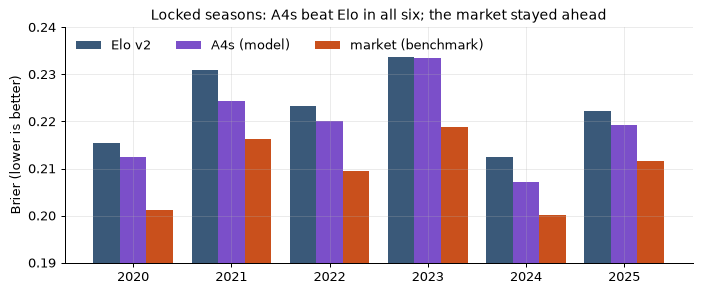

In [22]:
# LOADED: experiments/runs/20261003T215950Z_m3_signoff_*.json (the one holdout run, REG 2020-2025).
so = {r["name"].removeprefix("m3_signoff_"): r for r in RUNS if r["name"].startswith("m3_signoff_") and r["holdout"]}
print(f"n = {so['A4s']['n']:,} games, one games hash for every row: {len({r['games_hash'] for r in so.values()}) == 1}")
display(pd.DataFrame({k: so[k]["metrics"] for k in ["A4s", "elo_v2", "market", "A4bs"]}).T[["brier", "logloss", "accuracy", "ece"]].round(4))
for k, v in so["A4s"]["comparisons"].items():
    print(f"  {k:<26} {ci(v)}")
per = pd.DataFrame(so["A4s"]["per_season"]).set_index("season")
fig, ax = plt.subplots(figsize=(9, 3.4))
xs = np.arange(len(per))
for i, (col, lab, colr) in enumerate([("brier_elo_v2", "Elo v2", ELO), ("brier_A4s", "A4s (model)", MODEL), ("brier_market", "market (benchmark)", VEGAS)]):
    ax.bar(xs + (i - 1) * 0.27, per[col], width=0.27, color=colr, label=lab)
ax.set_xticks(xs, per.index); ax.set_ylim(0.19, 0.24); ax.set_ylabel("Brier (lower is better)")
ax.set_title("Locked seasons: A4s beat Elo in all six; the market stayed ahead"); ax.legend(ncol=3, loc="upper left")
plt.show()

**Verdict: pass.** A4s beat Elo by 0.0035 Brier, interval [−0.0063, −0.0007], in every one of the six seasons. Its ECE (0.028) missed the fixed 0.02 bar, but section 4 showed that bar was too tight for 1,615 games (Elo and the market missed it too). You marked M3 passed and recorded the bar as flawed; nothing was recalibrated after seeing the holdout. The market is still about 0.01 better. A4s is the live 2026 model. More in `notebooks/03_m3_results.ipynb`.

### Where Elo helps: the no-Elo study

You asked whether our features could stand without Elo, the way a typical ML model is built. The same machinery was run without `elo_logit` (development seasons only).

In [23]:
# LOADED: experiments/runs/20261005T033941Z_m3_noelo_N*.json (the no-Elo study, DEV 2006-2019).
noelo = {r["name"].removeprefix("m3_noelo_"): r for r in RUNS if r.get("study") == "no_elo"}
display(pd.DataFrame([{"id": k, "features": ", ".join(r["features"]), "Brier": round(r["metrics"]["brier"], 4),
                       "vs Elo": ci(r["comparisons"]["vs_elo_brier"]), "vs A4s": ci(r["comparisons"]["vs_A4s_brier"])}
                      for k, r in sorted(noelo.items())]).set_index("id"))
d = next(r["diagnostics"] for r in noelo.values() if r.get("diagnostics"))
bst = d["best"]
pd.DataFrame([{"weeks": r["bucket"], "games": r["n"], f"best no-Elo ({bst})": r[f"brier_{bst}"], "A4s": r["brier_A4s"],
               "Elo v2": r["brier_elo_v2"], f"{bst} minus Elo": ci(r["best_minus_elo"]), "A4s minus N2 (Elo's added value)": ci(r["A4s_minus_N2"])}
              for r in d["by_week_bucket"]]).set_index("weeks").round(4)

,features,Brier,vs Elo,vs A4s
id,,,,
N1,adj_epa_margin,0.2209,"+0.0030 [+0.0007, +0.0053]","+0.0058 [+0.0036, +0.0080]"
N2,"adj_epa_margin, qb_delta_diff",0.2183,"+0.0005 [-0.0021, +0.0033]","+0.0033 [+0.0016, +0.0049]"
N3,"adj_epa_margin, qb_delta_diff, rest_diff, neutral",0.2182,"+0.0004 [-0.0024, +0.0033]","+0.0031 [+0.0013, +0.0049]"
N4,"adj_pass_margin, adj_rush_margin, qb_delta_dif...",0.2188,"+0.0010 [-0.0018, +0.0039]","+0.0037 [+0.0019, +0.0056]"
N5,"adj_pass_margin, adj_rush_margin, qb_delta_dif...",0.2209,"+0.0030 [-0.0003, +0.0066]","+0.0058 [+0.0032, +0.0085]"
N6,"adj_epa_margin, qb_delta_diff, raw_epa_margin",0.2185,"+0.0007 [-0.0021, +0.0034]","+0.0034 [+0.0015, +0.0052]"


,games,best no-Elo (N3),A4s,Elo v2,N3 minus Elo,A4s minus N2 (Elo's added value)
weeks,,,,,,
1-4,751,0.2277,0.2243,0.2229,"+0.0049 [-0.0005, +0.0100]","-0.0038 [-0.0073, -0.0004]"
5-9,969,0.2167,0.2126,0.2140,"+0.0027 [-0.0022, +0.0080]","-0.0047 [-0.0081, -0.0016]"
10-18,1730,0.2149,0.2125,0.2178,"-0.0028 [-0.0066, +0.0011]","-0.0022 [-0.0045, +0.0004]"


Our features alone tie Elo overall (0.2182 vs 0.2178), and only with the QB term. Adding Elo back is worth 0.0033, mostly in weeks 1-9. By weeks 10-18 the no-Elo model is ahead of Elo. **Elo's edge is memory**: it carries a long, results-based view of each team across seasons, while the EPA ratings lean on a shrunk copy of last season early on. That pointed to a better early-season prior as the next lever, which is what the player and Kalman work in sections 8 and 9 tried.

## 6. Margin model and playoff odds

### The margin model

The margin model predicts the whole distribution of the final score margin, not just the winner. Its center is our **spread**. It uses A4s's three inputs in a linear regression, with a spread around the forecast of about 13.5 points. Football margins aren't a bell curve: scores come in 3s and 7s, so the model starts from a normal curve and multiplies each margin by a **key-number factor** learned on 2001-2005 only (3 comes up about 2.9 times as often as a smooth curve says, 7 about 1.9 times, a tie almost never).

In [24]:
# LOADED: experiments/runs/20261005T021003Z_m4_margin_keynum.json (DEV 2006-2019) and the M4 sign-off runs (2020-2025).
mk_dev = run("m4_margin_keynum"); mae = mk_dev["comparisons"]["mae"]
print(f"DEV 2006-2019 ({mk_dev['n']:,} games): average miss of the spread, model {mae['model']:.2f} pts, "
      f"Elo {mae['elo']:.2f}, Vegas {mae['market']:.2f} (benchmark). Model minus Elo {ci(mae['model_minus_elo'], 3)}")
m4 = {r["name"]: r for r in RUNS if r.get("signoff") == "m4_signoff" and r.get("holdout")}
mg, po = m4["m4_signoff_margin"]["result"], m4["m4_signoff_playoff_odds"]["result"]
print(f"Locked 2020-2025: model {mg['mae']['model']:.3f}, Elo {mg['mae']['elo']:.3f}, Vegas {mg['mae']['market']:.3f}; "
      f"model minus Elo {ci(mg['mae']['model_minus_elo'], 3)}  -> the interval includes zero: FAIL on the primary")

DEV 2006-2019 (3,450 games): average miss of the spread, model 10.67 pts, Elo 10.73, Vegas 10.49 (benchmark). Model minus Elo -0.064 [-0.118, -0.009]
Locked 2020-2025: model 10.126, Elo 10.185, Vegas 9.764; model minus Elo -0.059 [-0.150, +0.035]  -> the interval includes zero: FAIL on the primary


The margin model beat Elo's spread by about 0.06 points a game on both windows, but with half as many games in the locked window the interval includes zero, so it **failed** its pre-registered primary. It passed every secondary (its win chance matched A4s, its calibration passed, five of six spread bands were honest). You chose to keep it on the site with methodology text saying its edge over Elo's spread is not proven. Its real job is feeding the season simulation.

### How the NFL breaks ties

Playoff odds need seeding, and seasons end in ties on record all the time. `nflelo/ml/sim/tiebreak.py` implements the NFL's procedure: head-to-head, division record, common games, conference record, strength of victory, strength of schedule, the points steps, and a coin toss, with the special rules for three-team ties. It reproduces all 48 actual conference seedings from 2002 to 2025. Here it is live on 2015's AFC.

In [25]:
# LIVE: reproduce the 2015 AFC seeds from the actual results, with the tiebreak steps it used.
from nflelo.ml.sim import tiebreak
log = []
s15 = tiebreak.actual_standings(D.load_schedules([2015]), 2015, log)
print("AFC seeds:", [s15.st.teams[t] for t in s15.seeds()["AFC"]], "(actual: DEN, NE, CIN, HOU, KC, PIT)")
pd.DataFrame([x for x in log if set(x["group"]) & {"DEN", "NE", "CIN"}])[["kind", "group", "step", "chosen"]]

AFC seeds: ['DEN', 'NE', 'CIN', 'HOU', 'KC', 'PIT'] (actual: DEN, NE, CIN, HOU, KC, PIT)


,kind,group,step,chosen
0,wc,"(NE, CIN, DEN)",sweep,DEN
1,wc,"(NE, CIN)",common4,NE


Denver, New England and Cincinnati all finished 12-4. Denver beat both of the others, so the three-team sweep rule gave Denver the top seed. New England and Cincinnati then started over as a two-team tie; they hadn't played each other and had the same conference record, so it came down to common opponents, which New England won.

### Why strength shocks matter

The simplest season simulation plays out the remaining games thousands of times with each game's predicted chances. That ignores two things: our ratings are estimates, and teams really do get better or worse during a season. The result is overconfidence: good teams look like locks too early.

The fix: at the start of each simulated season, give every team one random **strength shock** (standard deviation τ = 4.5 points, tuned on 2006-2019), applied to all its remaining games. Here are 2,000 simulated seasons from the latest cached 2026 state, with and without the shock.

as of 2026-10-05 00:20 EDT, 209 games left


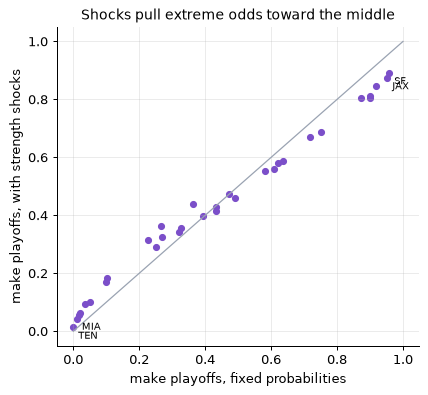

,"playoffs, tau 0","playoffs, tau 4.5","win SB, tau 0","win SB, tau 4.5"
team,,,,
SF,0.958,0.892,0.168,0.122
JAX,0.952,0.874,0.133,0.103
MIN,0.919,0.845,0.090,0.064
KC,0.899,0.813,0.076,0.064
SEA,0.900,0.806,0.164,0.120
BUF,0.872,0.806,0.082,0.069
BAL,0.752,0.686,0.048,0.058
NE,0.717,0.669,0.050,0.050


In [26]:
# LIVE: simulate the rest of 2026 from the cached state, 2,000 seasons with tau 0 and with tau 4.5.
from nflelo.ml.models import margin as mm
from nflelo.ml.sim import state, season as sim
m26 = json.loads((live.LIVE_DIR / "margin_2026.json").read_text())
fit26 = mm.MarginFit.from_dict(m26["fit"]); kn26 = mm.KeyNumbers.from_dict(m26["keynum"]) if m26["keynum"] else None
yrs = range(1999, 2027)
pbp_all = D.load_pbp(yrs, columns=["game_id", "posteam", "defteam", "play_type", "pass", "rush", "epa", "success", "wp",
                                   "two_point_attempt", "qb_dropback", "passer_id", "play_id"])
sch_all = asof.add_asof(D.load_schedules(yrs))
now = sch_all.loc[sch_all["home_score"].notna() & (sch_all["season"] == 2026), "kickoff"].max() + pd.Timedelta(hours=4)
played = games[pd.to_datetime(games["date"]) <= now.tz_convert("America/New_York").tz_localize(None)]
inp26, feats26, adj26 = state.state_at(pbp_all, sch_all, played[played["home_score"].notna()], 2026, now, fit26, m26["shape"], kn26)
odds0 = sim.simulate(inp26, 2000, tau=0.0, seed=20261004)
odds45 = sim.simulate(inp26, 2000, tau=sim.TAU_REST, seed=20261004)
del pbp_all
print(f"as of {now:%Y-%m-%d %H:%M %Z}, {int(inp26.remaining.sum())} games left")
cmp_ = pd.DataFrame({"playoffs, tau 0": odds0["playoffs"], "playoffs, tau 4.5": odds45["playoffs"],
                     "win SB, tau 0": odds0["win_sb"], "win SB, tau 4.5": odds45["win_sb"]})
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1)
ax.scatter(cmp_["playoffs, tau 0"], cmp_["playoffs, tau 4.5"], color=MODEL, s=22)
for t in cmp_["playoffs, tau 0"].sort_values().index[[0, 1, -1, -2]]:
    ax.annotate(t, (cmp_.at[t, "playoffs, tau 0"], cmp_.at[t, "playoffs, tau 4.5"]), fontsize=8, xytext=(4, -9), textcoords="offset points")
ax.set_xlabel("make playoffs, fixed probabilities"); ax.set_ylabel("make playoffs, with strength shocks")
ax.set_title("Shocks pull extreme odds toward the middle"); plt.show()
cmp_.sort_values("playoffs, tau 4.5", ascending=False).head(8).round(3)

Points above the diagonal on the left and below it on the right: with shocks, the long shots keep a real chance and the favorites stop looking like locks. On the development seasons the shocks roughly halved the made-playoffs calibration error (loaded in the cell after next).

The site's published odds come from the weekly job's 20,000-season run, logged in `experiments/live/sim_2026.csv`.

In [27]:
# LOADED: experiments/live/sim_2026.csv (the published playoff odds; one block per weekly run).
sims = live.read_sim(live.sim_path(2026))
latest = sims[sims["run_at_utc"] == sims["run_at_utc"].max()]
print(f"{sims['run_at_utc'].nunique()} logged runs; latest {sims['run_at_utc'].max()}, {int(latest['n_sims'].iloc[0]):,} seasons, tau {latest['tau_rest'].iloc[0]}")
latest.set_index("team")[["playoffs", "division", "seed1", "reach_sb", "win_sb", "wins_mean", "wins_p10", "wins_p90"]] \
      .sort_values("playoffs", ascending=False).head(10)

3 logged runs; latest 2026-10-07 19:50:38+00:00, 20,000 seasons, tau 4.5


,playoffs,division,seed1,reach_sb,win_sb,wins_mean,wins_p10,wins_p90
team,,,,,,,,
SF,0.8986,0.5342,0.3424,0.2286,0.1306,12.31,9.0,15.0
JAX,0.8832,0.7718,0.2507,0.2008,0.1040,11.69,9.0,14.0
MIN,0.8521,0.6062,0.2426,0.1526,0.0740,11.71,9.0,15.0
SEA,0.8220,0.3540,0.1918,0.2092,0.1206,11.43,9.0,14.0
KC,0.8208,0.5764,0.1878,0.1298,0.0624,11.07,8.0,14.0
BUF,0.7990,0.5466,0.1575,0.1507,0.0765,10.91,8.0,14.0
NE,0.6764,0.4006,0.0695,0.0970,0.0466,9.84,7.0,13.0
BAL,0.6746,0.3942,0.1143,0.1052,0.0520,10.33,7.0,13.0
DEN,0.5936,0.2590,0.0664,0.0891,0.0440,9.61,7.0,13.0


In [28]:
# LOADED: experiments/runs/20261005T024754Z_m4_signoff_*.json (the playoff-odds locked test, 2020-2025).
pm4 = po["metrics"]; rules = m4["m4_signoff_margin"]["rules"]
bt = run("m4_playoff_odds")["backtest"]["metrics"]["playoffs"]     # DEV 2006-2019 backtest (experiments/runs/*_m4_playoff_odds.json)
print(f"DEV 2006-2019: made-playoffs ECE {bt['ece_tau0']:.4f} without shocks -> {bt['ece']:.4f} with; Brier {bt['brier_tau0']:.4f} -> {bt['brier']:.4f}")
print(f"Made-playoffs Brier {pm4['playoffs']['brier']:.4f} vs {pm4['playoffs']['brier_tau0']:.4f} without shocks; "
      f"difference {ci(pm4['playoffs']['diff'], 4)}")
print(f"Made-playoffs ECE {pm4['playoffs']['ece']:.4f}, perfect-forecaster p95 {pm4['playoffs']['ece_null']['p95']:.4f}")
print(f"Margin model: {'PASS' if rules['margin_primary_pass'] else 'FAIL'}; playoff odds: {'PASS' if rules['odds_primary_pass'] else 'FAIL'}")

DEV 2006-2019: made-playoffs ECE 0.0386 without shocks -> 0.0181 with; Brier 0.1213 -> 0.1195
Made-playoffs Brier 0.1234 vs 0.1258 without shocks; difference -0.0024 [-0.0049, -0.0001]
Made-playoffs ECE 0.0282, perfect-forecaster p95 0.0441
Margin model: FAIL; playoff odds: PASS


**Playoff odds: pass** on every rule, and they're live on the site. **Margin model: fail** on the primary (kept, with the caveat stated). The tiebreakers are exact. Details, including the key-number chart and the τ tuning curve, are in `notebooks/04_margin_and_playoff_odds.ipynb`.

## 7. The live 2026 pipeline

A model's real test is games that haven't happened yet. From 2026 week 5 (Thursday 2026-10-08) every prediction is logged before kickoff in a public, append-only ledger.

**What runs when.** `.github/workflows/weekly.yml` runs on GitHub's servers twice a week:

- **Wednesday 14:00 UTC** (10:00 Eastern in daylight time): the main run, which predicts the whole week, Thursday game included.
- **Sunday 12:00 UTC** (08:00 Eastern): a refresh that picks up announced starting quarterbacks before the earliest Sunday kickoff (London games at 9:30 Eastern).

Each run does three steps and commits the result:

1. `scripts/build.py` re-downloads the nflverse schedule, rebuilds `data/games.csv`, reruns Elo and writes `outputs/`.
2. `scripts/ml_predict.py` builds the A4s features as of now, predicts every unplayed game, appends rows to `experiments/live/2026.csv`, logs the Kalman shadow model to `2026_shadow.csv`, and runs the 20,000-season simulation into `sim_2026.csv`.
3. `scripts/export_site.py` writes `site/data/*.json`, which the static site reads.

**The pre-kickoff rule.** The ledger writer refuses any row whose run time is at or after the game's kickoff, and the scorer filters again, so a hand-edited row can't sneak in. Each game is scored on its last prediction before kickoff, and its Wednesday prediction is scored separately. Because the file is append-only and every change is a git commit, the timestamps can be audited.

In [29]:
# LOADED: experiments/live/2026.csv (the public ledger). Market columns are read for display as a benchmark only.
ledger = live.read_ledger(live.ledger_path(2026), market=True)
late = int((ledger["run_at_utc"] >= ledger["kickoff_utc"]).sum())
print(f"{len(ledger):,} rows, {ledger['game_id'].nunique()} games, {ledger['run_at_utc'].nunique()} runs "
      f"({ledger['run_at_utc'].min():%Y-%m-%d} to {ledger['run_at_utc'].max():%Y-%m-%d}); model versions {sorted(ledger['model_version'].unique())}")
print(f"rows written at or after kickoff: {late}")
sel = live.latest_before_kickoff(ledger)
sel["week"] = sel["game_id"].str[5:7].astype(int)
now_utc = pd.Timestamp.now(tz="UTC")
upcoming = sel[sel["kickoff_utc"] > now_utc]
week = int(upcoming["week"].min()) if len(upcoming) else int(sel["week"].max())
shadow = live.read_shadow(live.shadow_path(2026))
shadow = shadow[shadow["run_at_utc"] < shadow["kickoff_utc"]].sort_values("run_at_utc").groupby("game_id").tail(1).set_index("game_id")
show = sel[sel["week"] == week].set_index("game_id").join(shadow[["p_home_shadow"]])
print(f"\nWeek {week} (as of this run): home win probability and spread (positive = home favored)")
show[["kickoff_utc", "p_home_model", "p_home_shadow", "p_home_elo", "p_home_market", "spread_model", "spread_elo",
      "spread_market", "qb_source"]].rename(columns={"p_home_model": "A4s", "p_home_shadow": "Kalman shadow", "p_home_elo": "Elo",
                                                      "p_home_market": "Vegas (benchmark)"}).round(3)

1,054 rows, 214 games, 5 runs (2026-10-04 to 2026-10-07); model versions ['A4s-2026-c6b394e8', 'A4s-2026-c6b394e8+M-2026-4aab0795']
rows written at or after kickoff: 0

Week 5 (as of this run): home win probability and spread (positive = home favored)


,kickoff_utc,A4s,Kalman shadow,Elo,Vegas (benchmark),spread_model,spread_elo,spread_market,qb_source
game_id,,,,,,,,,
2026_05_TB_DAL,2026-10-09 00:15:00+00:00,0.624,0.628,0.638,0.791,3.9,3.9,8.5,nflverse
2026_05_PHI_JAX,2026-10-11 13:30:00+00:00,0.696,0.721,0.687,0.748,6.6,5.5,7.0,nflverse
2026_05_CHI_GB,2026-10-11 17:00:00+00:00,0.503,0.474,0.429,0.428,0.1,-2.0,-2.5,nflverse
2026_05_CIN_MIA,2026-10-11 17:00:00+00:00,0.344,0.340,0.385,0.274,-4.6,-3.2,-6.5,nflverse
2026_05_CLE_NYJ,2026-10-11 17:00:00+00:00,0.394,0.431,0.422,0.543,-2.9,-2.2,2.5,nflverse
2026_05_HOU_TEN,2026-10-11 17:00:00+00:00,0.277,0.312,0.310,0.249,-7.0,-5.6,-7.5,nflverse
2026_05_IND_PIT,2026-10-11 17:00:00+00:00,0.586,0.556,0.604,0.572,2.8,2.9,2.5,nflverse
2026_05_LV_NE,2026-10-11 17:00:00+00:00,0.667,0.648,0.706,0.637,5.6,6.1,3.5,nflverse
2026_05_MIN_NO,2026-10-11 17:00:00+00:00,0.316,0.325,0.284,0.468,-5.4,-6.4,-1.5,nflverse


In [30]:
# LIVE: the live record so far, scored with the pipeline's own functions against data/games.csv results.
reg26 = games[(games["season"] == 2026) & (games["game_type"] == "REG")]
rec = live.live_record(ledger, live.results_frame(reg26.assign(home_team=reg26["home"], away_team=reg26["away"])),
                       live.LIVE_FROM_WEEK[2026])
f = rec["final"]
if f["n"] == 0:
    print(f"No live games scored yet: the record starts with week {live.LIVE_FROM_WEEK[2026]}, and data/games.csv has results "
          f"through week {int(reg26['week'].max())}. The next weekly run adds them.")
else:
    print(f"Scored games from week {f['from_week']}: {f['n']}. Model Brier {f['model']['brier']}, Elo {f['elo']['brier']}"
          + (f", Vegas {f['market_games']['market']['brier']} on {f['market_games']['n']} games" if 'market_games' in f else ""))

No live games scored yet: the record starts with week 5, and data/games.csv has results through week 4. The next weekly run adds them.


In [31]:
# LOADED: what the site reads (site/data/*.json, written by scripts/export_site.py and scripts/export_research.py).
sd = ROOT / "site" / "data"
pd.DataFrame([{"file": p.name, "KB": round(p.stat().st_size / 1024, 1)} for p in sorted(sd.glob("*.json"))]).set_index("file").T

file,headlines.json,history.json,ladder.json,luck.json,meta.json,ml.json,records.json,research.json,scorecard.json,tapestry.json,upcoming.json
KB,2.4,380.3,9.9,4.4,0.7,69.4,4.3,15.7,7.5,13.3,3.3


The site is two static pages (`site/index.html` for ratings, `site/models.html` for the models and their receipts) that fetch these JSON files. There is no server and no database, so any static host works. Hosting is parked until you pick the account and domain.

## 8. Player value (M5 and M5b)

The no-Elo study said early-season predictions need a better prior. The natural candidate is the roster: rate players, then rate the lineup that actually takes the field. Two attempts.

**M5, box-score credit (CC BY).** Each play's EPA is shared among the players the box score names (passer, target, ball carrier, tackler, sacker, and so on) by position, shrunk toward replacement level, and summed over each team's expected lineup. Lineups are probabilities, not yes/no: a Questionable player plays 60-87% of the time depending on position. The game model then got the difference between the lineup taking the field and the lineup its ratings remember.

**M5b, on-field ratings (RAPM, CC BY-SA).** Participation data lists all 22 players on every play since 2016. RAPM (regularized adjusted plus-minus) solves one big ridge regression in which each play's EPA equals the sum of the effects of everyone on the field. Linemen always play together, so the regression can't split credit among them on its own; the M5 box-score values serve as the prior that decides the split.

In [32]:
# LOADED: experiments/runs/20261005T044913Z_m5_B*.json (the M5 ladder, REG 2012-2019 with moneylines, vs A4s).
rows = []
for n in ["m5_B0", "m5_B1", "m5_B2", "m5_B3", "m5_B4", "m5_B5"]:
    r = run(n); c = r["comparisons"]["vs_B0_brier"]
    rows.append({"step": n[3:], "Brier": round(r["metrics"]["brier"], 4), "vs A4s [95% CI]": "" if n == "m5_B0" else ci(c),
                 "what it adds": r["notes"].split(". ")[0].rstrip(".")})
pd.DataFrame(rows).set_index("step")

,Brier,vs A4s [95% CI],what it adds
step,,,
B0,0.2147,,Reference: A4s as in M3 (trained 2001..S-1)
B1,0.2149,"+0.0002 [-0.0006, +0.0011]",lineup_delta_diff from box-score values
B2,0.2150,"+0.0004 [-0.0004, +0.0012]",lineup_delta_diff from with/without values
B3,0.2154,"+0.0008 [-0.0004, +0.0019]",B2 + preseason roster change (fading)
B4,0.2154,"+0.0008 [-0.0004, +0.0020]",B3 with offense/defense split
B5,0.2155,"+0.0008 [-0.0003, +0.0020]",B3 with 0/1 play probabilities


Every interval includes zero, so the one-SE rule keeps plain A4s. The lineup terms aren't noise (their coefficients are positive in every refit, and they move with the market), but the effect is small: one standard deviation of lineup news moves a game by about two percentage points, and most games have none. With about 2,000 test games the comparison can't see something that small. M5 is recorded as a **negative result** and never went to the locked test. More in `notebooks/05_player_values.ipynb`.

Here are the M5b on-field ratings for quarterbacks, fit on 2016-2019 (the ratings that would predict 2020), with 90% intervals and the box-score prior they started from.

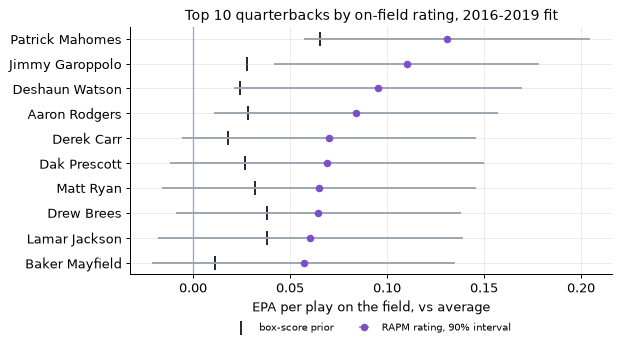

In [33]:
# LOADED: data/raw/ml/m5b/ratings_through_2019.parquet (local output of scripts/ml_m5b.py; CC BY-SA 4.0).
p = need(D.ML_DIR / "m5b" / "ratings_through_2019.parquet")
if p:
    rat = pd.read_parquet(p)
    qb = rat[rat["side_ok"] & rat["active"] & (rat["snaps_T"] >= 300) & (rat["group"] == "QB")]
    top10 = qb.sort_values("value", ascending=False).head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(7, 4))
    yy = np.arange(len(top10))
    ax.errorbar(top10["value"], yy, xerr=1.645 * top10["sd"], fmt="o", color=MODEL, ecolor=MUTED, ms=5, label="RAPM rating, 90% interval")
    ax.scatter(top10["prior_value"], yy, marker="|", color=INK, s=120, label="box-score prior")
    ax.set_yticks(yy, top10["name"]); ax.axvline(0, color=MUTED, lw=1)
    ax.set_xlabel("EPA per play on the field, vs average"); ax.set_title("Top 10 quarterbacks by on-field rating, 2016-2019 fit")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=8); plt.tight_layout(); plt.show()

In [34]:
# LOADED: experiments/runs/20261005T053831Z_m5b_signoff_rapm.json (the M5b locked test, 2020-2025, season-ahead).
r5b = run("m5b_signoff_rapm"); pooled = r5b["result"]["pooled"]
print(f"{pooled['n_plays']:,} plays in {pooled['n_games']:,} games; each season predicted from ratings fit on earlier seasons")
pd.DataFrame({"play EPA MSE": pooled["mse"],
              "RAPM minus this [95% CI]": {k: ci(v, 5) for k, v in r5b["comparisons"].items() if k in ("team", "box", "intercept")}}).fillna("")

177,545 plays in 1,693 games; each season predicted from ratings fit on earlier seasons


,play EPA MSE,RAPM minus this [95% CI]
rapm,1.887053,
team,1.888833,"-0.00178 [-0.00275, -0.00076]"
box,1.886082,"+0.00097 [+0.00015, +0.00179]"
intercept,1.895792,"-0.00874 [-0.01047, -0.00699]"


**M5b: fail.** On-field ratings beat team ratings (player-level information helps once rosters turn over), but they **lose to box-score values** summed over the same on-field players. With about 28,000 plays a season and five linemen always on the field together, individual on-field effects are too collinear and noisy to beat simple credit. The ratings stay as a descriptive player view with honest intervals; they don't feed the game model.

**What the two results teach.** Who is on the field matters (both player methods beat team ratings season-ahead), but with public data, individual credit beyond the quarterback is weak, and lineup news is too small to move game predictions in a test of this size. More in `notebooks/06_player_ratings.ipynb`.

## 9. The Kalman shadow model (M3b)

Elo answers one question each week: how good is each team? A **Kalman filter** answers two: how good, and **how sure are we**. Each team's strength is a normal distribution (a mean and a variance), and two steps repeat:

1. **Predict:** a week passes, so every team's variance grows a little (teams change).
2. **Update:** a game's margin arrives. The surprise (actual minus predicted margin) moves both teams' means, and the size of the move, the **Kalman gain**, depends on how uncertain we are. Early in a season the variance is large and ratings move a lot; later they settle.

So the filter learns its own step size, where Elo uses a fixed K. Here is the project's filter on a two-team toy: the same matchup eight weeks in a row, with home field switched off.

week,1,2,3,4,5,6,7,8
margin,14.00,3.00,-7.00,10.0,21.00,-3.00,7.00,0.00
predicted KC margin,0.00,4.18,3.91,1.8,3.16,5.78,4.62,4.91
SD of strength gap,8.49,7.18,6.36,5.8,5.39,5.08,4.84,4.64


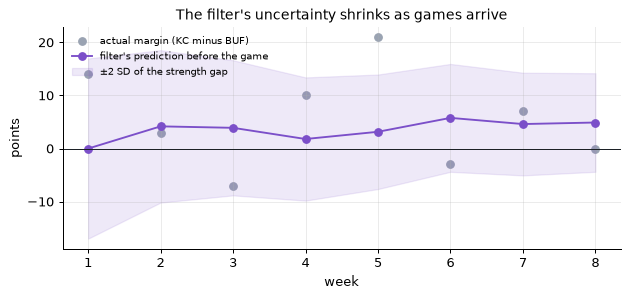

In [35]:
# LIVE: the real filter (nflelo/ml/features/kalman.py) on a two-team toy.
from nflelo.ml.features import kalman as kf
toy = pd.DataFrame({"game_id": [f"g{i}" for i in range(8)], "season": 2022, "week": range(1, 9), "home": "KC", "away": "BUF",
                    "neutral": True, "margin": [14, 3, -7, 10, 21, -3, 7, 0], "kick_ns": range(8), "ord": range(1, 9),
                    "epa_margin": np.nan})
res = kf.run_filter(toy, kf.KalmanConfig(q_week=0.5, sigma_m=13.0, p0=36.0, q_hfa=0.0))
toy["predicted KC margin"], toy["SD of strength gap"] = res.pred_mean, np.sqrt(res.pred_var)
display(toy[["week", "margin", "predicted KC margin", "SD of strength gap"]].round(2).set_index("week").T)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.scatter(toy["week"], toy["margin"], color=MUTED, label="actual margin (KC minus BUF)")
ax.plot(toy["week"], toy["predicted KC margin"], color=MODEL, marker="o", label="filter's prediction before the game")
ax.fill_between(toy["week"], toy["predicted KC margin"] - 2 * toy["SD of strength gap"],
                toy["predicted KC margin"] + 2 * toy["SD of strength gap"], color=MODEL, alpha=0.12, label="±2 SD of the strength gap")
ax.axhline(0, color=INK, lw=0.8); ax.set_xlabel("week"); ax.set_ylabel("points"); ax.legend(fontsize=8, loc="upper left")
ax.set_title("The filter's uncertainty shrinks as games arrive"); plt.show()

The band narrows from about ±17 points to about ±9 as the filter sees more of the matchup, and later surprises move the prediction less. The real filter tracks all 32 teams and home field together, with settings fit on 2000-2005 (weekly drift about 0.85 points, each off-season keeps about half of a team's distance from average). It also takes each game's EPA margin as a second measurement, which turned out to add only about 3% more information than the score. More, including the filter's view of 2006-2019, in `notebooks/07_game_model_refinement.ipynb`.

In [36]:
# LOADED: experiments/runs/20261005T062809Z_m3b_*.json (M3b ladder on DEV 2006-2019).
rows = []
for s in ["KF", "A4s", "C2d"]:
    r = run(f"m3b_{s}"); m = r["metrics"]
    rows.append({"model": {"KF": "Kalman filter alone", "A4s": "A4s (live model)", "C2d": "C2d: Elo + Kalman margin + QB delta"}[s],
                 "Brier": round(m["brier"], 4), "vs A4s [95% CI]": ci(r["comparisons"]["vs_a4s"], 5), "vs Elo": ci(r["comparisons"]["vs_elo"])})
display(pd.DataFrame(rows).set_index("model"))
sp = run("m3b_C2d")["splits"]
pd.DataFrame({k: {"games": v["n"], "C2d minus A4s [95% CI]": ci(v["vs_a4s"])} for k, v in sp.items()}).T

,Brier,vs A4s [95% CI],vs Elo
model,,,
Kalman filter alone,0.2167,"+0.00164 [-0.00045, +0.00360]","-0.0011 [-0.0029, +0.0007]"
A4s (live model),0.2151,"+0.00000 [+0.00000, +0.00000]","-0.0027 [-0.0043, -0.0011]"
C2d: Elo + Kalman margin + QB delta,0.2141,"-0.00095 [-0.00191, +0.00000]","-0.0037 [-0.0055, -0.0019]"


,games,C2d minus A4s [95% CI]
weeks_1_4,751,"-0.0006 [-0.0023, +0.0011]"
weeks_5_9,969,"-0.0002 [-0.0019, +0.0016]"
weeks_10_18,1730,"-0.0016 [-0.0029, -0.0002]"
changed,664,"-0.0000 [-0.0021, +0.0021]"
unchanged,2786,"-0.0012 [-0.0022, -0.0001]"


The filter alone beats Elo (0.2167 vs 0.2178, not significant). Swapping the ridge EPA margin for the filter's margin (C2d) improves A4s by about 0.001 Brier, with gains concentrated in weeks 10-18, but the interval's upper end is +0.000001: it touches zero, so the pre-set bar was **narrowly missed**.

**Why a shadow model instead of a locked test.** Running the holdout on a model that just missed its development bar would be moving the goalposts. Instead, C2d runs beside A4s in 2026: logged before kickoff in `experiments/live/2026_shadow.csv` on the same games, and scored next to A4s as results come in. That is a clean forward test on data no one has seen, and if it holds up it is the candidate for 2027. A4s stays the 2026 model.

In [37]:
# LOADED: experiments/live/2026_shadow.csv (the shadow ledger) and the published shadow record.
sh = live.read_shadow(live.shadow_path(2026))
print(f"{len(sh):,} shadow rows, {sh['game_id'].nunique()} games, version {sorted(sh['model_version'].unique())}")
print("Shadow record on the site:", research["live"]["shadow"])

417 shadow rows, 209 games, version ['C2d-2026-6b53b499']
Shadow record on the site: {'name': 'Kalman strength model (M3b)', 'n_scored': 0, 'brier': None, 'model_brier_same_games': None, 'brier_diff': None, 'ledger_url': 'https://github.com/walk-the-program/NFLELO/blob/main/experiments/live/2026_shadow.csv'}


## 10. The play model (M6)

M6 answers: *given the situation and the players on the field, how many yards will this play gain?* It predicts a **whole distribution** over 53 yard bins (10+ lost, each yard from −9 to +40, 41+, and touchdown), not a single number, because play outcomes aren't bell-shaped: incomplete passes put a spike at 0, sacks pull passes negative, and a few plays break for 40.

It only sees what both teams can see **at the snap**: down, distance, field position, score and clock, personnel groupings, formation, defenders in the box, and the two teams' ratings as of the start of the week. Not pass rushers, coverage, routes or pressure; a test enforces that list. There are two views: **situation** (the call is unknown) and **call** (run or pass is given, which fourth-down and play-calling tools need).

### CRPS: scoring a distribution

The **CRPS** (continuous ranked probability score) compares the forecast's cumulative distribution with the outcome, threshold by threshold, and sums the squared gaps. It is in yards, lower is better, and it rewards forecasts that put probability near what happened. A point forecast that is exactly right scores 0 and pays the full distance otherwise; a spread-out forecast never scores 0 but is cheaper on average when outcomes vary.

In [38]:
# LIVE: CRPS by the project's metric (nflelo/ml/plays/metrics.py) for two toy forecasts at midfield.
from nflelo.ml.plays import data as pdata, metrics as pmet
point = np.zeros(pdata.N_BINS); point[pdata.BIN_LABELS.index("0")] = 1.0                   # "it gains exactly 0"
yds = pdata.BIN_YARDS.copy(); spread_ = np.exp(-0.5 * ((yds - 3) / 3) ** 2); spread_[-1] = 0; spread_ /= spread_.sum()   # "about 3, give or take"
rows = {}
for gained in (0, 3, 8):
    b_ = np.array([pdata.BIN_LABELS.index(str(gained))]); yl = np.array([50.0])
    rows[f"actual {gained} yards"] = {"point forecast at 0": pmet.crps(point[None], b_, yl)[0],
                                      "spread around 3": pmet.crps(spread_[None], b_, yl)[0]}
pd.DataFrame(rows).round(2)

,actual 0 yards,actual 3 yards,actual 8 yards
point forecast at 0,0.0,3.00,8.00
spread around 3,1.8,0.69,3.43


### Four situations from a model trained on development seasons

A quick fit of the chosen model type (gradient-boosted trees over the 53 bins, call view) on 2016-2018, with the settings the development run picked for 2019. Then four made-up plays from the offense's own 45: 3rd and 2 vs 3rd and 9, run vs pass, everything else typical (11 personnel in the shotgun, six in the box, tied mid-game, average teams).

111,961 plays 2016-2019; trained on 84,029 plays (2016-2018), {'learning_rate': 0.1, 'max_leaf_nodes': 7}, 46 trees, 19s in all


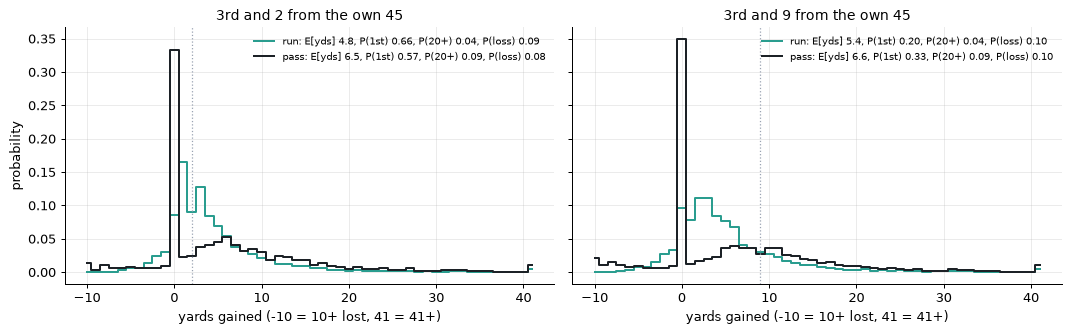

In [39]:
# LIVE: load the 2016-2019 play table (scripts/ml_m6.py), fit the call-view GBM on 2016-2018, predict four plays.
import ml_m6
from nflelo.ml.plays import gbm
t0 = time.perf_counter()
world = ml_m6.load_world(2019, priors={})
T6 = world.table
dev6 = json.loads(p.read_text()) if (p := need(D.ML_DIR / "m6" / "dev.json")) else None
g = (dev6 or {}).get("fits", {}).get("call_2019", {}).get("gbm", {})
params, n_iter, tov_iter = g.get("chosen", {"learning_rate": 0.1, "max_leaf_nodes": 7}), g.get("n_iter", 46), g.get("tov_iter", 83)
m6 = gbm.fit(T6[T6["season"] <= 2018], "call", params, n_iter=n_iter, tov_iter=tov_iter)
print(f"{len(T6):,} plays 2016-2019; trained on {m6.info['n_train']:,} plays (2016-2018), {params}, {n_iter} trees, "
      f"{time.perf_counter() - t0:.0f}s in all")

typical = {"down": 3, "yardline_100": 55, "score_diff": 0, "half_secs": 600, "game_secs": 2400, "off_timeouts": 3,
           "def_timeouts": 3, "home": 1, "roof_indoor": 0, "roof_open": 0, "temp": 60, "wind": 5, "off_rb": 1, "off_te": 1,
           "off_wr": 3, "off_ol": 5, "def_dl": 4, "def_lb": 2, "def_db": 5, "form_shotgun": 1, "form_pistol": 0,
           "form_under_center": 0, "box": 6, "off_pass_o": 0, "off_rush_o": 0, "def_pass_d": 0, "def_rush_d": 0}
base = T6[T6["season"] == 2019].iloc[[0]]
X = pd.concat([base.assign(**typical, ydstogo=ytg, is_pass=ip) for ytg in (2, 9) for ip in (0, 1)], ignore_index=True)
P, _ = m6.predict(X)
ev = pmet.event_probs(P, X["ydstogo"].to_numpy(float), X["yardline_100"].to_numpy(float))
ey = pmet.expected_yards(P, X["yardline_100"].to_numpy(float))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
xb = np.arange(-10, 42)
for ax, ytg in zip(axes, (2, 9)):
    for i in X.index[X["ydstogo"] == ytg]:
        lab = "pass" if X.at[i, "is_pass"] == 1 else "run"
        ax.step(xb, P[i, :52], where="mid", color=INK if lab == "pass" else GOOD, lw=1.6,
                label=f"{lab}: E[yds] {ey[i]:.1f}, P(1st) {ev['first'][i]:.2f}, P(20+) {ev['20plus'][i]:.2f}, P(loss) {ev['loss'][i]:.2f}")
    ax.axvline(ytg, color=MUTED, ls=":", lw=1)
    ax.set_title(f"3rd and {ytg} from the own 45"); ax.set_xlabel("yards gained (-10 = 10+ lost, 41 = 41+)")
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("probability"); plt.tight_layout(); plt.show()

The run is a tight hump around 2-5 yards with a small chance of a loss. The pass has the incompletion spike at 0 (about a third of the mass), a long right tail, and its own loss risk from sacks. On 3rd and 2 the run converts more often; on 3rd and 9 only the pass gives a real chance. That's what football people already know; the point is that the model gets it from data, with calibrated probabilities a decision tool can use.

In [40]:
# LOADED: experiments/runs/20261005T090009Z_m6_signoff_*.json (the M6 locked test, season-ahead 2020-2025).
rows = []
for view in ("situation", "call"):
    gb, bl = run(f"m6_signoff_{view}_gbm"), run(f"m6_signoff_{view}_baseline")
    cal = gb["result"]["cal_first"]
    rows.append({"view": view, "plays": gb["n"], "baseline CRPS": round(bl["metrics"]["crps"], 4), "GBM CRPS": round(gb["metrics"]["crps"], 4),
                 "GBM minus baseline [95% CI]": ci(gb["result"]["vs_baseline"]["crps"]),
                 "P(1st down) ECE": round(cal["ece"], 4), "perfect-model p95": round(cal["null_p95"], 4), "passes (0.01 floor)": cal["ok"]})
pd.DataFrame(rows).set_index("view")

,plays,baseline CRPS,GBM CRPS,GBM minus baseline [95% CI],P(1st down) ECE,perfect-model p95,passes (0.01 floor)
view,,,,,,,
situation,177545,3.8617,3.8436,"-0.0181 [-0.0198, -0.0164]",0.0068,0.0033,True
call,177545,3.7902,3.7713,"-0.0189 [-0.0206, -0.0172]",0.0074,0.0032,True


**M6: pass in both views.** The model beats the situational baseline (historical yards by down, distance and field zone) in every season, both data eras (NGS and FTN) and every down and field-zone split. The gain looks small (about 0.02 yards of CRPS on about 3.8) because most of a play's outcome isn't predictable before the snap; what matters is that it is consistent. Calibration passed on the 0.01 floor, which was set before the holdout; at 177,000 plays every model fails the strict statistical band, the baseline included. Knowing the 22 players' identities added about 10% of the gain. More in `notebooks/08_play_model.ipynb`.

## 11. Decision support (M7)

### Our own win-probability model

Every decision is valued in win probability, so the project needed a WP model it controls. nflfastR's WP was trained on seasons that include our test seasons, and its `vegas_wp` uses the betting line. Ours uses the game state (score, clock, down, distance, field position, timeouts, who gets the second-half kickoff) plus **A4s's pregame probability** where nflfastR's market version uses the spread. It is gradient boosting with monotone constraints: more points, better field position or an extra timeout can never lower WP.

In [41]:
# LOADED: experiments/runs/*_m7a_wp.json, *_m7a_bench_*.json (dev 2018-2019) and *_m7a_signoff_*.json (locked 2020-2025).
rows = []
for lab, pre in (("dev 2018-2019", "m7a_"), ("locked 2020-2025", "m7a_signoff_")):
    w = run(f"{pre}wp")
    rows.append({"window": lab, "plays": w["n"], "ours": w["metrics"]["brier"], "nflfastR wp": run(f"{pre}bench_nflfastr_wp")["metrics"]["brier"],
                 "vegas_wp (benchmark)": run(f"{pre}bench_vegas_wp")["metrics"]["brier"],
                 "ours minus nflfastR [95% CI]": ci(w["diffs"]["m7a_wp-nflfastr_wp"]["brier"]), "ours ECE": w["metrics"]["ece"]})
pd.DataFrame(rows).set_index("window").round(4)

,plays,ours,nflfastR wp,vegas_wp (benchmark),ours minus nflfastR [95% CI],ours ECE
window,,,,,,
dev 2018-2019,75104,0.1429,0.1527,0.1380,"-0.0098 [-0.0180, -0.0014]",0.0047
locked 2020-2025,233913,0.1559,0.1659,0.1497,"-0.0099 [-0.0146, -0.0055]",0.0092


**WP model: pass.** On the locked seasons it beats nflfastR's public WP by about 0.01 Brier with an interval that excludes zero, while using no market input. The market version is still better (it knows more than A4s does). It is CC BY, like the game model.

### One fourth down, worked through

For each fourth down the engine computes the team's WP after each option:

- **Go:** M6 (call view) gives the yards distribution for a run and for a pass, mixed by how often teams run in that spot; each outcome's next state is valued with the WP model.
- **Field goal:** a make-probability model by distance, roof, wind, cold and kicker; then the WP after a make or a miss.
- **Punt:** a distribution of where the receiving team starts; then that state's WP.

All components here are fit on seasons before 2019, then applied to a real 2019 play: the largest model-estimated miss among 2019 punts.

In [42]:
# LIVE: refit every fourth-down component for 2019 (on 2006-2018; M6 on 2016-2018) and value one real play.
import ml_m7a
from nflelo.ml.decisions import fourth as fd
from nflelo.ml.wp import model as wpm
from nflelo.ml.decisions import kicking as kk
t0 = time.perf_counter()
inp7 = ml_m7a.load_inputs(2019)                                    # play-by-play through 2019, A4s, WP states, M6 table
wp19 = wpm.without_calibration(wpm.fit_season_ahead(inp7.wp_table, 2019))
comp19, _ = fd.fit_components(2019, inp7.pbp, inp7.wp_table, inp7.m6_table, wp=wp19)
print(f"components fit in {time.perf_counter() - t0:.0f}s")

dec19 = fd.decision_table(inp7.pbp, inp7.a4s, seasons=[2019])
fp = need(D.ML_DIR / "m7a" / "fourth_m7adev.parquet")
if fp:
    FOURTH = pd.read_parquet(fp)
    ex = FOURTH[(FOURTH["season"] == 2019) & (FOURTH["choice"] == "punt")].sort_values("lost", ascending=False).iloc[0]
    d1 = dec19[(dec19["game_id"] == ex["game_id"]) & (dec19["play_id"] == ex["play_id"])].reset_index(drop=True)
else:   # the same play, found directly: LAC at CHI, 2019 week 8, 4th and 1 late in the fourth quarter
    ex = None
    d1 = dec19[(dec19["game_id"] == "2019_08_LAC_CHI") & (dec19["posteam"] == "LAC") & (dec19["qtr"] == 4)
               & (dec19["ydstogo"] == 1)].tail(1).reset_index(drop=True)
gi = fd.go_inputs(d1, comp19, inp7.ratings)
v = fd.option_values(comp19, d1, gi)
r0 = d1.iloc[0]
print(f"\n{r0['posteam']} vs {r0['defteam']}, 2019 week {r0['week']}, {ml_m7a.clock(r0['qtr'], r0['game_secs'])}, "
      f"leading by {r0['score_diff']:+.0f}, 4th and {r0['ydstogo']:.0f}, {r0['yardline_100']:.0f} yards from the end zone")
if ex is not None:
    print("what happened:", ex["desc"][:150])
print(f"pregame A4s win probability for {r0['posteam']}: {r0['a4s_prob']:.3f}")
print(f"GO:   P(convert) {v['p_conv'][0]:.3f} (run {v['p_conv_run'][0]:.3f}, pass {v['p_conv_pass'][0]:.3f}) -> WP {v['wp_go'][0]:.3f}")
print(f"FG:   {r0['yardline_100'] + kk.FG_DIST_OFFSET:.0f}-yard try, P(make) {v['p_fg'][0]:.3f} -> WP {v['wp_fg'][0]:.3f}")
print(f"PUNT: -> WP {v['wp_punt'][0]:.3f}")
if ex is not None:
    print(f"Recommendation: {ex['best']} by {ex['margin']:.3f} WP; 90% band from 50 refits [{ex['band_lo']:.3f}, {ex['band_hi']:.3f}] "
          f"({'toss-up' if ex['tossup'] else 'clear call'}) -- band loaded from data/raw/ml/m7a/fourth_m7adev.parquet")
del inp7

inputs through 2019: pbp 984,639 rows, A4s 3,584 games, WP states 529,839, M6 plays 111,961 (16s)


components fit in 103s



LAC vs CHI, 2019 week 8, Q4 1:45, leading by +1, 4th and 1, 76 yards from the end zone
what happened: (1:45) (Punt formation) 1-T.Long punts 58 yards to CHI 18, Center-45-C.Mazza. 29-T.Cohen to CHI 35 for 17 yards (49-D.Tranquill).
pregame A4s win probability for LAC: 0.313
GO:   P(convert) 0.673 (run 0.736, pass 0.500) -> WP 0.521
FG:   94-yard try, P(make) 0.000 -> WP 0.147
PUNT: -> WP 0.391
Recommendation: go by 0.131 WP; 90% band from 50 refits [0.050, 0.268] (clear call) -- band loaded from data/raw/ml/m7a/fourth_m7adev.parquet


The Chargers led by a point with under two minutes left, 4th and 1 at their own 24, and punted. Going for it converts about two times in three and, if it works, lets them run out most of the clock; the punt only pushes Chicago back. The model says the punt gave up about 0.13 win probability. The **uncertainty band** comes from refitting all four components on 50 resampled versions of the training data: when the band for "best option minus second best" excludes zero the call is clear, otherwise it's a toss-up (about half of all fourth downs are). More, including where each option's value comes from, in `notebooks/09_fourth_down.ipynb`.

### The audit, and the fourth-down result

In [43]:
# LOADED: experiments/runs/20261005T173539Z_m7a_signoff_audit.json and _conversion.json (locked 2020-2025).
a = run("m7a_signoff_audit")["metrics"]
print(f"{a['n']:,} fourth downs in {a['games']:,} games (model-estimated). Teams chose {a['choice_counts']}; "
      f"the model recommended {a['recommended_counts']}.")
print(f"Teams matched the recommendation on {a['matched_share']:.1%} of fourth downs ({a['matched_share_clear_calls']:.1%} of clear calls); "
      f"{a['tossup_share']:.1%} were toss-ups.")
print(f"Estimated win probability given up: {a['wp_lost_total']:.1f} wins over six seasons, {a['wp_lost_per_team_game']:.3f} per team-game; "
      f"punts {a['wp_lost_by_choice']['punt']:.1f}, field goals {a['wp_lost_by_choice']['fg']:.1f}, go-for-its {a['wp_lost_by_choice']['go']:.1f}")
cv = run("m7a_signoff_conversion")["metrics"]["engine_on_attempts"]
print(f"\nConversion calibration on {cv['n']:,} actual go attempts: ECE {cv['cal']['ece']:.4f} vs limit "
      f"{max(cv['cal']['null_p95'], cv['cal']['floor']):.4f} -> {'pass' if cv['cal']['ok'] else 'FAIL'} "
      f"(predicted {cv['cal']['mean_pred']:.3f}, actual {cv['cal']['observed']:.3f})")

22,576 fourth downs in 1,610 games (model-estimated). Teams chose {'punt': 12298, 'fg': 5689, 'go': 4589}; the model recommended {'go': 9381, 'punt': 7863, 'fg': 5332}.
Teams matched the recommendation on 66.7% of fourth downs (79.8% of clear calls); 51.8% were toss-ups.
Estimated win probability given up: 97.9 wins over six seasons, 0.030 per team-game; punts 66.6, field goals 22.0, go-for-its 9.2

Conversion calibration on 4,589 actual go attempts: ECE 0.0272 vs limit 0.0216 -> FAIL (predicted 0.518, actual 0.539)


**Fourth-down tool: fail** on one component. The WP model, field goals and punts all passed, but the go-for-it conversion probability missed its calibration limit (ECE 0.027 against 0.022), mainly under-predicting 4th and 2. The audit is published anyway, labeled model-estimated: teams give up about 0.03 wins per team-game on fourth downs, mostly by punting.

### M7a-v2: the fix, and its 2026 forward test

The holdout is spent, so the fix was built on development seasons 2018-2019 only. The diagnosis: the miss came from the play model's fourth-down bias when the call is given, plus garbage-time states the play model never trained on, not from the run/pass mix. The chosen fix, **v2ad**, mixes run and pass by distance and field zone and adds fourth-down conversion offsets. It was frozen before any 2026 game.

In [44]:
# LOADED: experiments/runs/20261006T005703Z_m7a_v2_*.json (dev 2018-2019) and experiments/m7a_v2/frozen_2026.json.
rows = []
for k in ("ref_v1", "v2a", "v2ad"):
    r = run(f"m7a_v2_{k}"); m = r["metrics"]
    rows.append({"engine": k, "go attempts": r["n"], "conversion ECE": round(m["ece"], 4), "perfect-model p95": round(m["cal"]["null_p95"], 4),
                 "Brier": round(m["brier"], 4), **{g: round(s["actual_minus_pred"]["diff"], 3) for g, s in r["selection"].items()}})
display(pd.DataFrame(rows).set_index("engine"))
fz = ROOT / "experiments" / "m7a_v2" / "frozen_2026.json"
frozen = json.loads(fz.read_text())
ft = research["forward_test"]
days = (date.fromisoformat(ft["runs_after"]) - date.today()).days
print(f"Frozen engine: {frozen['engine']} candidate {frozen['candidate']}, season {frozen['season']}, frozen at commit {ft['frozen_commit']}")
print(f"Forward test status: {ft['status']} ({days} days from today). "
      f"Result file present: {(ROOT / 'experiments' / 'm7a_v2' / 'forward_2026.json').exists()}")

,go attempts,conversion ECE,perfect-model p95,Brier,4th-and-1,4th-and-2,4th-and-3-5,4th-and-6+,4th-and-1-2
engine,,,,,,,,,
ref_v1,1118,0.0332,0.0457,0.2305,-0.017,0.034,-0.011,0.069,-0.004
v2a,1118,0.0333,0.0461,0.2303,-0.014,0.037,-0.012,0.067,-0.001
v2ad,1118,0.0190,0.0435,0.2304,-0.007,0.004,-0.034,0.046,-0.005


Frozen engine: M7a-v2 candidate v2ad, season 2026, frozen at commit 5a0b850
Forward test status: Frozen at 5a0b850, runs after 2027-02-15 (128 days from today). Result file present: False


The selection columns are actual minus predicted conversion by distance; v2ad brings 4th and 2 from +0.034 to +0.004 and the overall ECE from 0.033 to 0.019. The forward test runs once, after the 2026 participation file is released (earliest 2027-02-15), with no refit. A 2026-only pass is weak evidence (about 800 attempts gives a wide band), so a pooled 2026+2027 test is also pre-registered (earliest 2028-02-15).

### M7b: early-down play calling

The question: on 1st and 2nd down, which personnel grouping and which call (run or pass) gains the most? This is a **causal** question, and raw averages answer it badly: teams choose heavy personnel at the goal line, where no play can gain many yards, so heavy sets look bad for reasons that have nothing to do with the call.

The method, in plain terms:

- A **propensity model** estimates how likely each of 12 actions (personnel × run/pass) is in each situation. Actions that teams almost never use in a spot (below 5%) are never estimated or recommended there.
- **AIPW** (augmented inverse-propensity weighting) combines an outcome model (built on M6) with the propensities. It is "doubly robust": it stays unbiased if either piece is right.
- **OPE** (off-policy evaluation) asks the final question on seasons the method never saw: if teams had followed the recommendations, how much EPA per play would they have gained compared with what they actually did?
- A **placebo**, with the actions shuffled, should show no gain. If it did, the pipeline itself would be manufacturing results.

In [45]:
# LOADED: experiments/runs/20261005T183521Z_m7b_signoff_*.json (the M7b locked test, season-ahead 2020-2025).
o = run("m7b_signoff_ope")["metrics"]
print(f"{o['n']:,} early-down plays. Recommended minus observed, EPA per play: {ci(o['ope_epa'])}  (pass if the lower bound > 0)")
print(f"Placebo (shuffled actions):                     {ci(run('m7b_signoff_placebo')['metrics']['ope_epa'])}  (should include 0)")
print(f"Success rate gain:                              {ci(o['ope_succ'])}")
for nm, lab in (("m7b_signoff_ope_thr10", "overlap threshold 0.10"), ("m7b_signoff_ope_trim10", "weights trimmed at 10")):
    print(f"Sensitivity, {lab:<24}           {ci(run(nm)['metrics']['ope_epa'])}")
print(f"The policy applies to {o['share_policy_applies']:.1%} of plays, worth {o['epa_per_affected_play']:+.3f} EPA per affected play")
recs = run("m7b_signoff_policy")["metrics"]["recs"]["main"]
best = pd.DataFrame({s: v["best_counts"] for s, v in recs.items()}).fillna(0).astype(int)
best["all seasons"] = best.sum(axis=1)
print("\nBest action in the 'clear' cells, by season (cells out of 60):")
best.sort_values("all seasons", ascending=False)

122,917 early-down plays. Recommended minus observed, EPA per play: +0.0524 [+0.0377, +0.0670]  (pass if the lower bound > 0)
Placebo (shuffled actions):                     +0.0058 [-0.0007, +0.0124]  (should include 0)
Success rate gain:                              +0.0407 [+0.0351, +0.0464]
Sensitivity, overlap threshold 0.10             +0.0453 [+0.0334, +0.0569]
Sensitivity, weights trimmed at 10              +0.0538 [+0.0398, +0.0675]
The policy applies to 66.7% of plays, worth +0.079 EPA per affected play

Best action in the 'clear' cells, by season (cells out of 60):


,2020,2021,2022,2023,2024,2025,all seasons
12_pass,12,14,12,11,13,14,76
11_pass,5,7,7,8,5,3,35
11_run,1,0,0,2,2,2,7
oth_run,0,0,1,1,1,0,3


**M7b: pass.** Following the recommendations would have gained about 0.05 EPA per early-down play on the unseen seasons, and the placebo's interval includes zero. The advice is consistent every season: **pass more on early downs, mostly from 12 personnel (one back, two tight ends) and 11 personnel, especially on 1st and 10.**

The caveats, stated plainly:

- The placebo's upper end (+0.012) hints at a small leftover bias, perhaps 0.005 EPA per play, well below the +0.052 gain.
- OPE and the placebo test the method, not **unmeasured confounding**: teams may know things we don't (injuries, the game plan).
- **Game theory:** if every team passed more from 12 personnel, defenses would adjust. These are marginal shifts from current tendencies, not a fixed optimal strategy.

More, including the goal-line confounding example and a Minnesota 2019 team view, in `notebooks/10_play_calling.ipynb`.

## 12. Where it stands and what's next

### Pass and fail

In [46]:
# LOADED: site/data/research.json (counts) and the scoreboard from section 0.
cnt = research["counts"]
print(f"{cnt['holdout_tested']} models tested once on the locked 2020-2025 seasons: {cnt['holdout_pass']} passed, {cnt['holdout_fail']} failed. "
      f"Plus {cnt['negative']} negative development result and {cnt['shadow']} shadow model running live.")
board[["model", "verdict", "result"]]

8 models tested once on the locked 2020-2025 seasons: 5 passed, 3 failed. Plus 1 negative development result and 1 shadow model running live.


,model,verdict,result
id,,,
M3,Game model,Pass,"-0.0035 [-0.0063, -0.0007]"
M4-margin,Margin model,Fail,"-0.059 [-0.150, +0.035]"
M4-odds,Playoff odds,Pass,"-0.0024 [-0.0049, -0.0001]"
M5,Lineup values,Negative result,"+0.0008 [-0.0004, +0.0019]"
M5b,On-field player ratings,Fail,"+0.0010 [+0.0002, +0.0018]"
M3b,Kalman strength model,"Not tested, shadow live","-0.0010 [-0.0019, +0.0000]"
M6,Play outcome model,Pass,"-0.0181 [-0.0198, -0.0164]"
M7a-wp,Win-probability model,Pass,"-0.0099 [-0.0146, -0.0055]"
M7a-4th,Fourth-down tool,Fail,0.027 against a limit of 0.022


What the evidence says, in five lines:

1. **The quarterback is most of the story.** Nearly all of the game model's gain over Elo comes from knowing the actual starter.
2. **Player-level beats team-level, but public data limits individual credit.** On-field plus-minus doesn't beat box-score credit, and lineup news is too small to move game predictions measurably.
3. **Elo's edge is memory.** Our features alone tie Elo; Elo wins early in the season, our features win late.
4. **Teams are still too conservative.** Model-estimated: about 0.03 wins per team-game given up on fourth downs, mostly by punting; and early downs should feature more passing, especially from 12 personnel.
5. **The market is still better at game prediction** (0.2096 vs 0.2195 Brier on 2020-2025). Our models are independent of it by design, so the measured edges over Elo and nflfastR are real.

### Waiting on data

In [47]:
# LIVE: what is waiting on 2026 (and 2027) data, with dates.
today = date.today()
waits = pd.DataFrame([
    ("Live record (A4s vs Elo vs Vegas)", "every Wednesday and Sunday", "2026 week 5 on (from 2026-10-08)",
     f"{research['live']['model']['n_scored']} games scored at the last export"),
    ("Kalman shadow (C2d vs A4s)", "same runs, same games", "2026 season; candidate for 2027", f"{research['live']['shadow']['n_scored']} scored"),
    ("M7a-v2 forward test (2026)", "once, after the 2026 participation release", "earliest 2027-02-15",
     f"{(date(2027, 2, 15) - today).days} days away"),
    ("M7a-v2 pooled 2026+2027 test", "once, after the 2027 participation release", "earliest 2028-02-15",
     f"{(date(2028, 2, 15) - today).days} days away"),
], columns=["what", "when it runs", "window", "status"]).set_index("what")
waits

,when it runs,window,status
what,,,
Live record (A4s vs Elo vs Vegas),every Wednesday and Sunday,2026 week 5 on (from 2026-10-08),0 games scored at the last export
Kalman shadow (C2d vs A4s),"same runs, same games",2026 season; candidate for 2027,0 scored
M7a-v2 forward test (2026),"once, after the 2026 participation release",earliest 2027-02-15,128 days away
M7a-v2 pooled 2026+2027 test,"once, after the 2027 participation release",earliest 2028-02-15,493 days away


### The site, hosting and open items

- **Site:** built (`site/index.html` for ratings and the matchup instrument, `site/models.html` for the models and their receipts), restyled in Soft Form with dark and light themes. It reads `site/data/*.json`, refreshed by the weekly Action. Next on the site track: readable research write-ups from the method docs, then game and team pages, then QB and player pages.
- **Hosting (parked, yours):** recommended Cloudflare Pages, publishing `site/` with no build step. It needs you to create the account and pick the domain; Claude does the rest.
- **GitHub cache purge (parked, yours):** the support request to purge the cached pre-rewrite commits is drafted in `context/pending/github-purge-request.txt` and needs your signed-in browser to submit.
- **Monetization:** not a goal. If that changes, revisit the share-alike (CC BY-SA) data and get legal advice first.

### Glossary

| Term | Meaning |
|---|---|
| **AIPW** | Augmented inverse-propensity weighting. A causal estimate that combines an outcome model with propensity weights; "doubly robust" because it stays unbiased if either piece is right. |
| **As-of rule** | A game's features use only games that kicked off before the earliest kickoff of its week. |
| **Box-score credit** | Sharing a play's EPA among the players the box score names (passer, target, tackler...), by position (M5). |
| **Brier score** | Mean squared error of a probability forecast; 0.25 is a coin flip, lower is better. |
| **Calibration** | Whether events happen as often as predicted (70% calls win about 70% of the time). |
| **CC BY / CC BY-SA** | Creative Commons licenses. CC BY needs credit; CC BY-SA also requires anything built from the data to carry the same license. |
| **CRPS** | Continuous ranked probability score. Scores a whole forecast distribution against the outcome, in the outcome's units (yards, points); lower is better. |
| **Development (dev) window** | Seasons used to build and compare models (2006-2019 for game models; 2018-2019 for participation-based ones). |
| **ECE** | Expected calibration error: the average gap between predicted and observed rates across probability bins. |
| **ECE null band / 0.01 floor** | The ECE range a perfectly calibrated model shows at the same sample size; at play level a model also passes at ECE ≤ 0.01. |
| **Elo logit** | Elo's home-win log-odds, frozen at the start of the week; A4s's first input. |
| **EP / EPA** | Expected points from a down, distance and spot; EPA is EP after the play minus EP before. |
| **Forward test** | Scoring a frozen model on a future season it was never fit to. |
| **Holdout (locked)** | 2020-2025, scored once per milestone under pre-registered rules. |
| **Kalman filter** | A rating system that tracks each team's strength and its uncertainty, so the step size adapts. |
| **Key numbers** | Margins like 3 and 7 that occur far more often than a smooth curve predicts. |
| **Leakage** | A feature that secretly contains information from after the prediction time. |
| **Log loss** | Average negative log-probability of what happened; punishes confident misses harder than Brier. |
| **Margin model** | A forecast of the full final-margin distribution; its center is the model spread. |
| **One-SE rule** | Pick the simplest model whose score is within one standard error of the best. |
| **OPE** | Off-policy evaluation: estimating how a different decision policy would have performed, from data generated by the actual one. |
| **Opponent-adjusted EPA** | Offense and defense ratings from a ridge regression that accounts for who each team played. |
| **Paired bootstrap** | Resampling the same games for both models to get an interval for their difference; clustered by game for play-level data. |
| **Placebo test** | Rerunning the pipeline with shuffled actions; a real method should find no gain. |
| **Pre-registration** | Writing and committing the pass/fail rules before the test data is scored. |
| **Propensity** | The probability that a team chooses a given action in a given situation. |
| **QB delta** | This week's starter's value minus the QB play the team's ratings remember. |
| **RAPM** | Regularized adjusted plus-minus: a ridge regression of play outcomes on all 22 players on the field. |
| **Ridge regression** | Regression with a penalty that pulls estimates toward a prior (zero or a supplied value). |
| **Shadow model** | A candidate model logged alongside the live one on the same games, without being shown as the headline. |
| **Strength shock (τ)** | A random season-long change in a team's strength in the playoff simulation; τ = 4.5 points. |
| **WP** | Win probability for the team with the ball, given the game state. |

In [48]:
# LIVE: total runtime of this notebook.
print(f"Notebook ran in {(time.perf_counter() - NB_START) / 60:.1f} minutes.")

Notebook ran in 2.3 minutes.
